<a href="https://colab.research.google.com/github/nashwanadilah/Customer-Churn-Prediction/blob/main/Code_Tugas_Akhir_Ildat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix)
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import joblib
import json

drive.mount('/content/drive')
path = "/content/drive/My Drive/"

df = pd.read_csv(path + 'lifelapse.csv',na_values=["-1"], sep=',', engine='python')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.shape

(185560, 20)

In [ ]:
df.head()

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,SEX,POLICY TYPE 1,POLICY TYPE 2,POLICY TYPE 3,PAYMENT MODE,POLICY STATUS,BENEFIT,NON LAPSE GUARANTEED,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,Full Benefit?,Policy Year (Decimal),Policy Year,Premium,Issue Date
0,1,1,1,36,F,1,1,A,Annually,Inforce,200000.0,NO NLG,0.0,0,0.0,N,8.000000,9,280.0,11-Aug
1,1,1,1,42,M,1,2,A,Annually,Inforce,100000.0,NO NLG,0.0,0,0.0,N,8.000000,9,200.0,11-Aug
2,1,1,2,40,M,2,3,A,Annually,Lapse,80000.0,NO NLG,0.0,0,0.0,N,8.000000,9,1289.0,11-Aug
3,1,1,3,39,M,1,2,A,Monthly,Lapse,100000.0,NO NLG,0.0,0,0.0,N,8.000000,9,216.0,11-Aug
4,1,1,4,44,M,1,2,A,Annually,Lapse,100000.0,NO NLG,0.0,0,0.0,N,7.916667,8,140.0,11-Sep


In [ ]:
# melihat variabel target
df['POLICY STATUS'].value_counts()

,count
POLICY STATUS,
Lapse,98865
Inforce,65814
Surrender,20233
Death,513
Expired,135


In [ ]:
# buat variabel target menjadi Churn
df.rename(columns={
    "POLICY STATUS": "CHURN"
}, inplace=True)

In [ ]:
# buat kategorinnya menjadi yes dan no
df['CHURN'] = df['CHURN'].map({
    "Lapse": "Yes",
    "Expired": "Yes",
    "Surrender": "Yes",
    "Death": "No",
    "Inforce": "No"
})

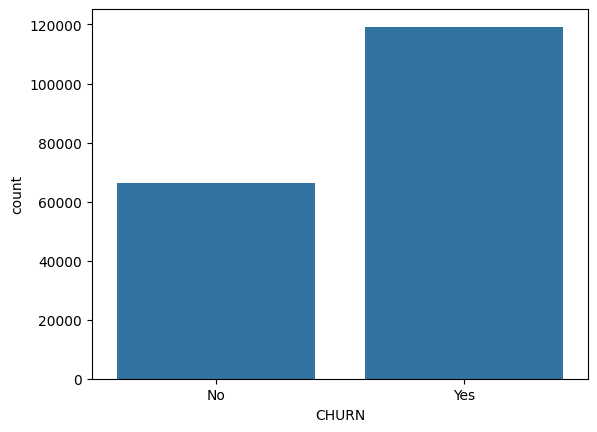

In [ ]:
sns.countplot(x=df['CHURN'])
plt.show()

# Preprocessing

In [ ]:
missing_stats = []
for col in df.columns:
    missing_stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(missing_stats, columns=['variabel', 'unique values', '% missing', '% kategori terbesar', 'data type'])
stats_df.sort_values('% missing', ascending=False)

,variabel,unique values,% missing,% kategori terbesar,data type
18,Premium,2864,41.564454,41.564454,float64
10,BENEFIT,2799,12.752748,18.045915,float64
0,CHANNEL1,8,0.000000,58.354171,int64
1,CHANNEL2,3,0.000000,61.112309,int64
3,ENTRY AGE,71,0.000000,3.572429,int64
2,CHANNEL3,83,0.000000,61.112848,int64
6,POLICY TYPE 2,88,0.000000,20.337896,int64
4,SEX,2,0.000000,57.913882,object
7,POLICY TYPE 3,5,0.000000,40.233348,object
8,PAYMENT MODE,5,0.000000,76.311705,object


In [ ]:
df.describe()

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,POLICY TYPE 1,POLICY TYPE 2,BENEFIT,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,Policy Year (Decimal),Policy Year,Premium
count,185560.000000,185560.000000,185560.000000,185560.000000,185560.000000,185560.000000,1.618960e+05,185560.000000,185560.000000,185560.000000,185560.000000,185560.000000,108433.000000
mean,3.600065,2.572322,7.966200,32.119309,5.033014,21.893490,2.344718e+04,0.252834,0.000517,170.330490,3.284277,3.826822,1273.247877
std,1.991486,0.567780,13.693194,12.827964,3.533662,19.124646,6.182418e+04,5.002793,0.030968,2917.944237,1.832295,1.849674,5836.882869
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000e+01,-99.000000,0.000000,0.000000,0.000000,1.000000,-111.000000
25%,2.000000,2.000000,0.000000,25.000000,3.000000,6.000000,8.000000e+02,0.000000,0.000000,0.000000,1.833333,2.000000,120.000000
50%,2.000000,3.000000,0.000000,32.000000,3.000000,13.000000,1.200000e+04,0.000000,0.000000,0.000000,3.250000,4.000000,432.000000
75%,6.000000,3.000000,11.000000,41.000000,6.000000,37.000000,2.000000e+04,0.000000,0.000000,0.000000,4.666667,5.000000,960.000000
max,8.000000,3.000000,82.000000,70.000000,20.000000,88.000000,5.000000e+06,250.000000,5.000000,266017.236800,8.000000,9.000000,444000.000000


In [ ]:
#cek data terduplikasi
df.duplicated().sum()

np.int64(13857)

In [ ]:
df.isnull().sum()

,0
CHANNEL1,0
CHANNEL2,0
CHANNEL3,0
ENTRY AGE,0
SEX,0
POLICY TYPE 1,0
POLICY TYPE 2,0
POLICY TYPE 3,0
PAYMENT MODE,0
CHURN,0


In [ ]:
df = df.dropna(subset=['BENEFIT', 'Premium'])

In [ ]:
df.isnull().sum()

,0
CHANNEL1,0
CHANNEL2,0
CHANNEL3,0
ENTRY AGE,0
SEX,0
POLICY TYPE 1,0
POLICY TYPE 2,0
POLICY TYPE 3,0
PAYMENT MODE,0
CHURN,0


In [ ]:
# Jumlah data setelah menghilangkan missing value
df.shape

(89084, 20)

In [ ]:
#sama seperti policy year (decimal), cuma kurang spesifik aja makanya di drop
df = df.drop(columns=['Policy Year'])

In [ ]:
df.describe()

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,POLICY TYPE 1,POLICY TYPE 2,BENEFIT,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,Policy Year (Decimal),Premium
count,89084.000000,89084.000000,89084.000000,89084.000000,89084.000000,89084.000000,8.908400e+04,89084.000000,89084.000000,89084.000000,89084.000000,89084.000000
mean,4.032542,2.490750,9.478066,32.714034,6.496980,28.077646,3.379786e+04,0.526647,0.000415,354.794640,2.979696,1316.617889
std,2.082799,0.564522,14.012964,12.438795,4.120989,22.505504,7.832972e+04,7.210322,0.029013,4203.565108,1.792331,5530.653144
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,3.000000e+01,-99.000000,0.000000,0.000000,0.000000,-111.000000
25%,2.000000,2.000000,0.000000,25.000000,3.000000,5.000000,1.000000e+04,0.000000,0.000000,0.000000,1.416667,120.000000
50%,4.000000,3.000000,0.000000,32.000000,6.000000,32.000000,2.000000e+04,0.000000,0.000000,0.000000,3.083333,480.000000
75%,6.000000,3.000000,14.000000,41.000000,8.000000,41.000000,4.000000e+04,0.000000,0.000000,0.000000,4.166667,1110.000000
max,8.000000,3.000000,82.000000,70.000000,20.000000,84.000000,5.000000e+06,250.000000,5.000000,266017.236800,8.000000,427053.000000


In [ ]:
df['CHANNEL1'].nunique()

8

In [ ]:
df['CHURN'] = df['CHURN'].map({'Yes': 1, 'No': 0})

In [ ]:
df['CHURN'] = df['CHURN'].astype(int)

In [ ]:
X = df.drop('CHURN', axis=1)
y = df['CHURN']

# Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
all_col = list(X_train.columns)
all_col_count = len(all_col)
print("Total No. of Features in the Dataset:")
print(all_col_count)

all_features = X_train.columns
print("All Features in the Dataset:")
print(all_features)

Total No. of Features in the Dataset:
18
All Features in the Dataset:
Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'SEX', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'POLICY TYPE 3', 'PAYMENT MODE', 'BENEFIT',
       'NON LAPSE GUARANTEED', 'SUBSTANDARD RISK', 'NUMBER OF ADVANCE PREMIUM',
       'INITIAL BENEFIT', 'Full Benefit?', 'Policy Year (Decimal)', 'Premium',
       'Issue Date'],
      dtype='object')


# Heatmap Korelasi

In [ ]:
def color(val):
    color = 'green' if val == 1 else 'red' if val < -0.5 else 'blue' if val > 0.5 else 'black'
    return 'color: %s' % color

In [ ]:
corr = X_train[X_train.columns].select_dtypes(include=['number']).corr()
corr.style.map(color)

,CHANNEL1,CHANNEL2,CHANNEL3,ENTRY AGE,POLICY TYPE 1,POLICY TYPE 2,BENEFIT,SUBSTANDARD RISK,NUMBER OF ADVANCE PREMIUM,INITIAL BENEFIT,Policy Year (Decimal),Premium
CHANNEL1,1.000000,-0.654584,0.604352,0.025178,0.169189,0.249228,-0.081577,-0.038840,-0.014371,0.121920,-0.202096,-0.133683
CHANNEL2,-0.654584,1.000000,-0.628131,0.062087,0.086376,0.006220,0.038540,0.020173,0.013280,0.077410,-0.087508,0.111807
CHANNEL3,0.604352,-0.628131,1.000000,-0.063802,-0.038545,0.021744,-0.066876,-0.029387,-0.009957,-0.058041,-0.042040,-0.106063
ENTRY AGE,0.025178,0.062087,-0.063802,1.000000,0.139890,0.155775,0.066403,0.075501,0.006179,0.076094,-0.116889,0.072488
POLICY TYPE 1,0.169189,0.086376,-0.038545,0.139890,1.000000,0.953808,0.014404,-0.027799,-0.007854,0.138168,-0.607953,0.018403
POLICY TYPE 2,0.249228,0.006220,0.021744,0.155775,0.953808,1.000000,0.011099,-0.024721,-0.010391,0.118460,-0.537370,0.018310
BENEFIT,-0.081577,0.038540,-0.066876,0.066403,0.014404,0.011099,1.000000,0.092607,-0.000175,0.025345,-0.041874,0.421150
SUBSTANDARD RISK,-0.038840,0.020173,-0.029387,0.075501,-0.027799,-0.024721,0.092607,1.000000,-0.001086,-0.006329,0.009562,0.101421
NUMBER OF ADVANCE PREMIUM,-0.014371,0.013280,-0.009957,0.006179,-0.007854,-0.010391,-0.000175,-0.001086,1.000000,-0.001259,-0.010937,0.007377
INITIAL BENEFIT,0.121920,0.077410,-0.058041,0.076094,0.138168,0.118460,0.025345,-0.006329,-0.001259,1.000000,-0.110273,-0.019100


In [ ]:
X_train_nom = X_train[all_features].select_dtypes(include=['object'])
print(X_train_nom.columns)

X_train_numeric = X_train[all_features].select_dtypes(include=['number'])
print(X_train_numeric.columns)

Index(['SEX', 'POLICY TYPE 3', 'PAYMENT MODE', 'NON LAPSE GUARANTEED',
       'Full Benefit?', 'Issue Date'],
      dtype='object')
Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'BENEFIT', 'SUBSTANDARD RISK',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'Policy Year (Decimal)',
       'Premium'],
      dtype='object')


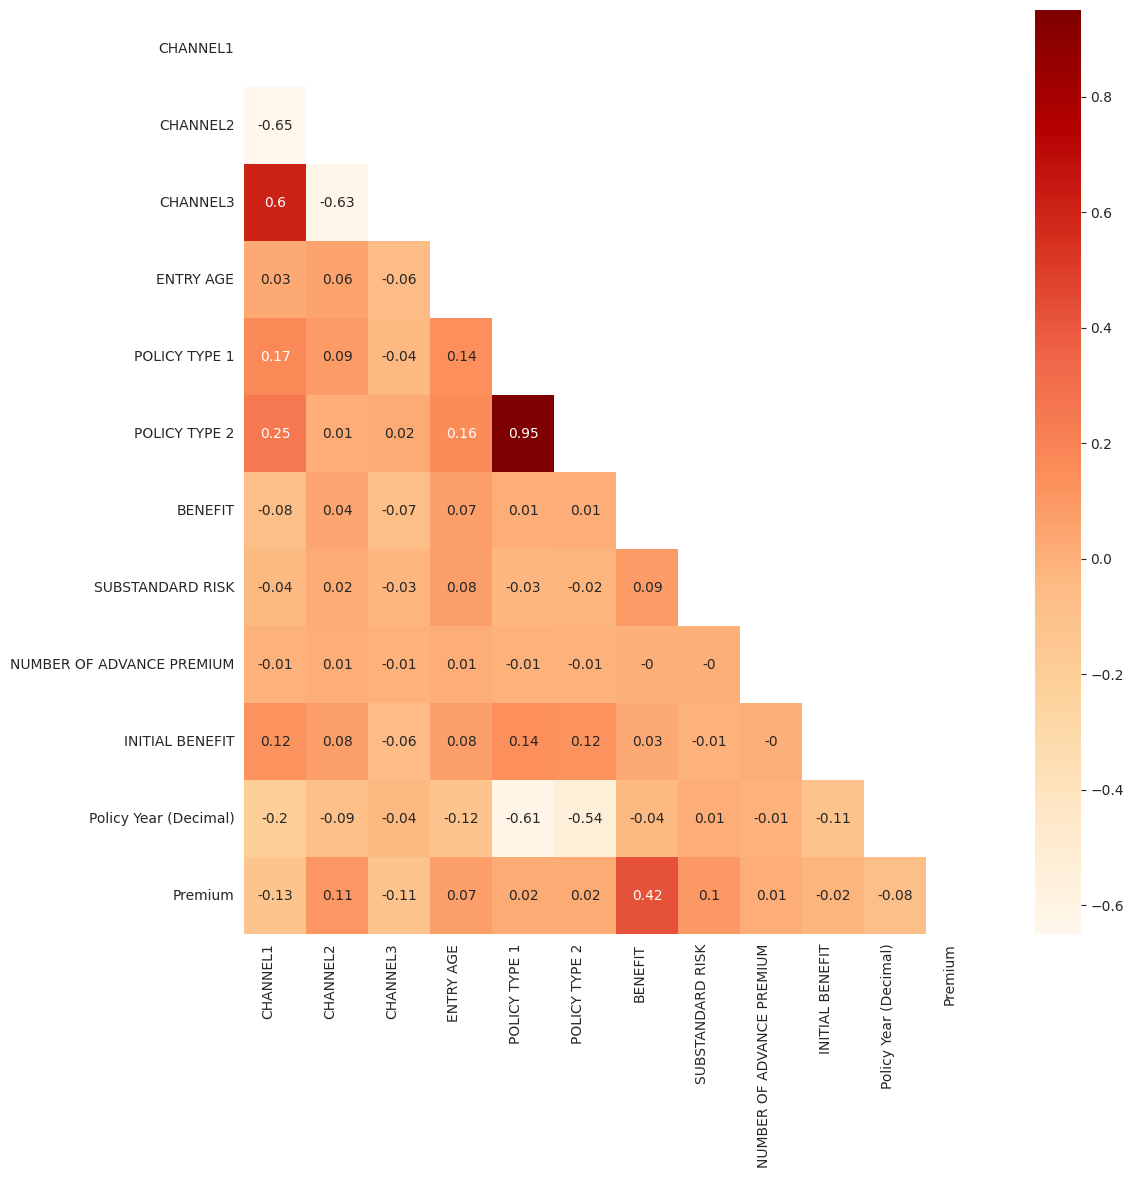

In [ ]:
corr_matrix = X_train_numeric.corr().round(2)

sns.set_style('white')
fig, ax = plt.subplots(figsize=(12, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

ax = sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='OrRd')

ax.set_xticklabels(ax.xaxis.get_ticklabels(), fontsize=10, ha='right', rotation=90)
ax.set_yticklabels(ax.yaxis.get_ticklabels(), fontsize=10, va="center", rotation=0)

plt.show()

In [ ]:
#mencari variabel dengan korelasi tinggi (>0.5)
correlation_threshold = 0.5

highly_correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
            colname = corr_matrix.columns[i]
            highly_correlated_features.add(colname)

highly_correlated_features

{'CHANNEL2', 'CHANNEL3', 'POLICY TYPE 2', 'Policy Year (Decimal)'}

# EDA

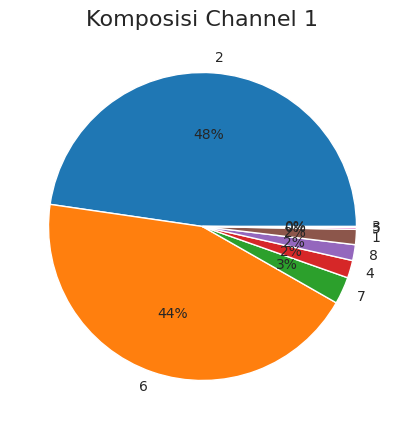

In [ ]:
# KOMPOSISI CHANNEL 1
plt.figure(figsize =(6,5))
plt.pie(df['CHANNEL1'].value_counts(), labels=df['CHANNEL1'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Channel 1', size = 16)
plt.show()

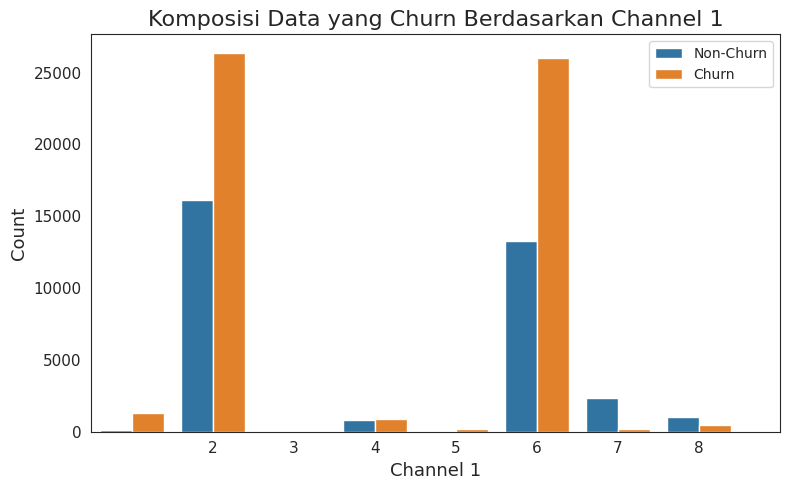

In [ ]:
# KOMPOSISI CHURN BERDASARKAN CHANNEL 1
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CHANNEL1', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Channel 1', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8])

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Channel 1", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN CHANNEL 1
fraud_by_channel1 = df.groupby(['CHANNEL1', 'CHURN']).size().reset_index(name='Count')
total_by_channel1 = df.groupby('CHANNEL1').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_channel1 = fraud_by_channel1.merge(total_by_channel1, on='CHANNEL1')

# PERSENTASE
merged_channel1['Percentage'] = (merged_channel1['Count'] / merged_channel1['Total_Count']) * 100
merged_channel1['Percentage'] = merged_channel1['Percentage'].round(2).astype(str) + '%'
merged_channel1['CHURN'] = merged_channel1['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_channel1)

    CHANNEL1 CHURN  Count  Total_Count Percentage
0          1    No     91         1418      6.42%
1          1   Yes   1327         1418     93.58%
2          2    No  16152        42495     38.01%
3          2   Yes  26343        42495     61.99%
4          3   Yes     74           74     100.0%
5          4    No    786         1646     47.75%
6          4   Yes    860         1646     52.25%
7          5    No      7          190      3.68%
8          5   Yes    183          190     96.32%
9          6    No  13245        39239     33.75%
10         6   Yes  25994        39239     66.25%
11         7    No   2381         2539     93.78%
12         7   Yes    158         2539      6.22%
13         8    No   1028         1483     69.32%
14         8   Yes    455         1483     30.68%


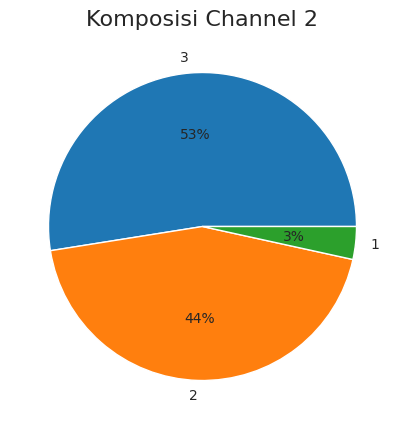

In [ ]:
# KOMPOSISI CHANNEL 2
plt.figure(figsize =(6,5))
plt.pie(df['CHANNEL2'].value_counts(), labels=df['CHANNEL2'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Channel 2', size = 16)
plt.show()

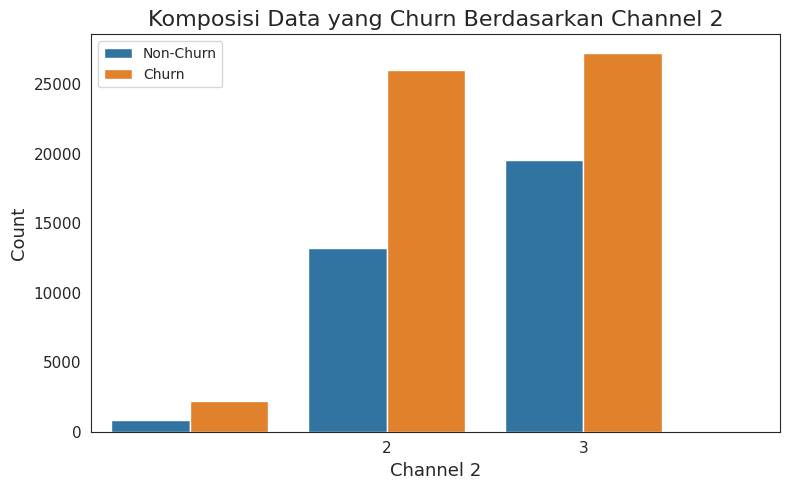

In [ ]:
# KOMPOSISI CHURN BERDASARKAN CHANNEL 2
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CHANNEL2', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Channel 2', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP
plt.xticks([1, 2, 3])

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Channel 2", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN CHANNEL 2
fraud_by_channel2 = df.groupby(['CHANNEL2', 'CHURN']).size().reset_index(name='Count')
total_by_channel2 = df.groupby('CHANNEL2').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_channel2 = fraud_by_channel2.merge(total_by_channel2, on='CHANNEL2')

# PERSENTASE
merged_channel2['Percentage'] = (merged_channel2['Count'] / merged_channel2['Total_Count']) * 100
merged_channel2['Percentage'] = merged_channel2['Percentage'].round(2).astype(str) + '%'
merged_channel2['CHURN'] = merged_channel2['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_channel2)

   CHANNEL2 CHURN  Count  Total_Count Percentage
0         1    No    877         3063     28.63%
1         1   Yes   2186         3063     71.37%
2         2    No  13245        39240     33.75%
3         2   Yes  25995        39240     66.25%
4         3    No  19568        46781     41.83%
5         3   Yes  27213        46781     58.17%


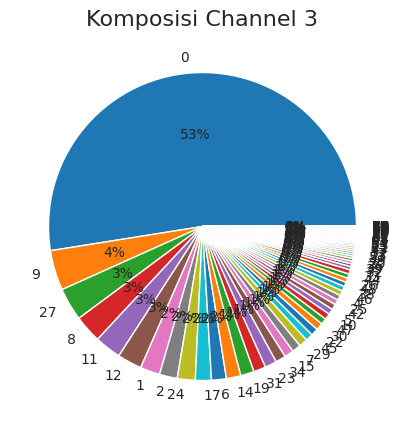

In [ ]:
# KOMPOSISI CHANNEL 3
plt.figure(figsize =(6,5))
plt.pie(df['CHANNEL3'].value_counts(), labels=df['CHANNEL3'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Channel 3', size = 16)
plt.show()

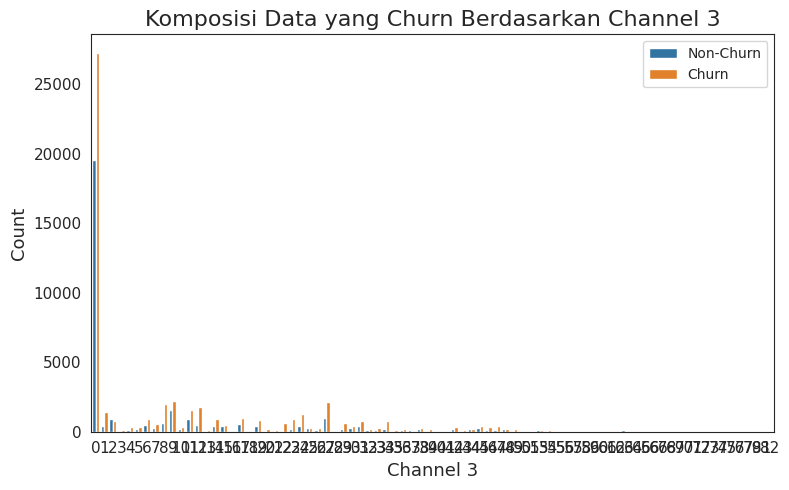

In [ ]:
# KOMPOSISI CHURN BERDASARKAN CHANNEL 3
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CHANNEL3', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Channel 3', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Channel 3", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN CHANNEL 3
fraud_by_channel3 = df.groupby(['CHANNEL3', 'CHURN']).size().reset_index(name='Count')
total_by_channel3 = df.groupby('CHANNEL3').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_channel3 = fraud_by_channel3.merge(total_by_channel3, on='CHANNEL3')

# PERSENTASE
merged_channel3['Percentage'] = (merged_channel3['Count'] / merged_channel3['Total_Count']) * 100
merged_channel3['Percentage'] = merged_channel3['Percentage'].round(2).astype(str) + '%'
merged_channel3['CHURN'] = merged_channel3['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_channel3)

     CHANNEL3 CHURN  Count  Total_Count Percentage
0           0    No  19569        46782     41.83%
1           0   Yes  27213        46782     58.17%
2           1    No    430         1844     23.32%
3           1   Yes   1414         1844     76.68%
4           2    No    920         1674     54.96%
..        ...   ...    ...          ...        ...
143        76    No      3            3     100.0%
144        77    No      1            1     100.0%
145        79    No      1            1     100.0%
146        81    No      1            1     100.0%
147        82   Yes      1            1     100.0%

[148 rows x 5 columns]


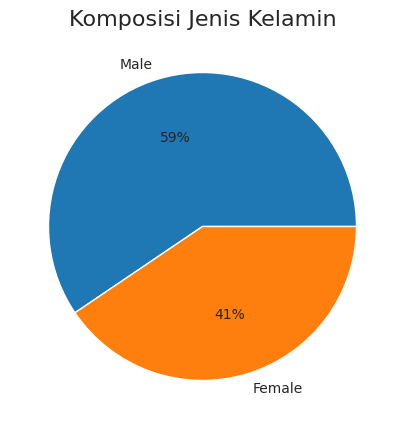

In [ ]:
# KOMPOSISI SEX
plt.figure(figsize =(6,5))
plt.pie(df['SEX'].value_counts(), labels=['Male', 'Female'], autopct='%.0f%%')
plt.title('Komposisi Jenis Kelamin', size = 16)
plt.show()

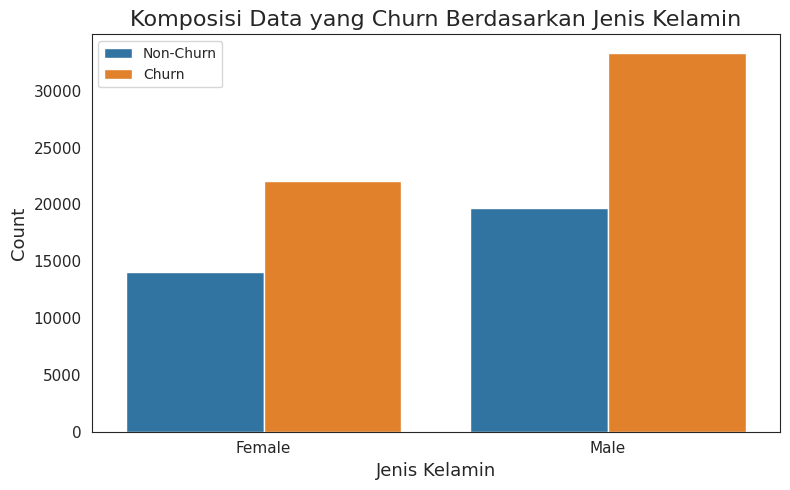

In [ ]:
# KOMPOSISI CHURN BERDASARKAN SEX
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='SEX', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Jenis Kelamin', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP
plt.xticks(['M', 'F'], ["Male", "Female"] )

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Jenis Kelamin", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN JENIS KELAMIN
fraud_by_sex = df.groupby(['SEX', 'CHURN']).size().reset_index(name='Count')
total_by_sex = df.groupby('SEX').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_sex = fraud_by_sex.merge(total_by_sex, on='SEX')

# PERSENTASE
merged_sex['Percentage'] = (merged_sex['Count'] / merged_sex['Total_Count']) * 100
merged_sex['Percentage'] = merged_sex['Percentage'].round(2).astype(str) + '%'
merged_sex['CHURN'] = merged_sex['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_sex)

  SEX CHURN  Count  Total_Count Percentage
0   F    No  14021        36107     38.83%
1   F   Yes  22086        36107     61.17%
2   M    No  19669        52977     37.13%
3   M   Yes  33308        52977     62.87%


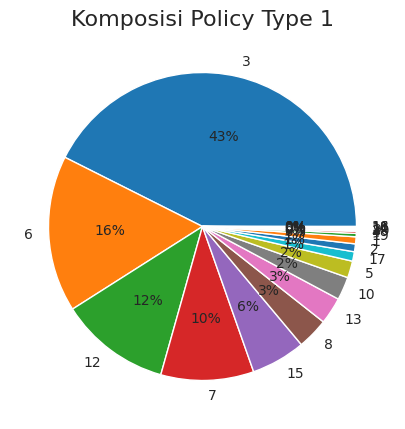

In [ ]:
# KOMPOSISI POLICY TYPE 1
plt.figure(figsize =(6,5))
plt.pie(df['POLICY TYPE 1'].value_counts(), labels=df['POLICY TYPE 1'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Policy Type 1', size = 16)
plt.show()

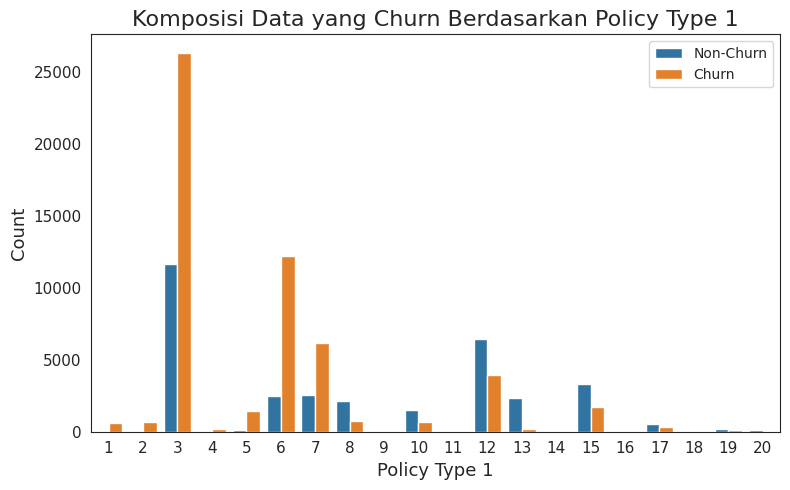

In [ ]:
# KOMPOSISI CHURN BERDASARKAN POLICY TYPE 1
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='POLICY TYPE 1', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Policy Type 1', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Policy Type 1", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN POLICY TYPE 1
fraud_by_policytype1 = df.groupby(['POLICY TYPE 1', 'CHURN']).size().reset_index(name='Count')
total_by_policytype1 = df.groupby('POLICY TYPE 1').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_policytype1 = fraud_by_policytype1.merge(total_by_policytype1, on='POLICY TYPE 1')

# PERSENTASE
merged_policytype1['Percentage'] = (merged_policytype1['Count'] / merged_policytype1['Total_Count']) * 100
merged_policytype1['Percentage'] = merged_policytype1['Percentage'].round(2).astype(str) + '%'
merged_policytype1['CHURN'] = merged_policytype1['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_policytype1)

    POLICY TYPE 1 CHURN  Count  Total_Count Percentage
0               1    No     34          654       5.2%
1               1   Yes    620          654      94.8%
2               2    No     24          734      3.27%
3               2   Yes    710          734     96.73%
4               3    No  11649        37937     30.71%
5               3   Yes  26288        37937     69.29%
6               4    No      7          190      3.68%
7               4   Yes    183          190     96.32%
8               5    No    133         1573      8.46%
9               5   Yes   1440         1573     91.54%
10              6    No   2454        14633     16.77%
11              6   Yes  12179        14633     83.23%
12              7    No   2525         8690     29.06%
13              7   Yes   6165         8690     70.94%
14              8    No   2146         2918     73.54%
15              8   Yes    772         2918     26.46%
16              9    No     33          104     31.73%
17        

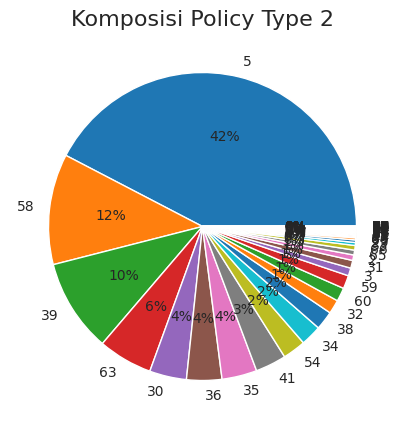

In [ ]:
# KOMPOSISI POLICY TYPE 1
plt.figure(figsize =(6,5))
plt.pie(df['POLICY TYPE 2'].value_counts(), labels=df['POLICY TYPE 2'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Policy Type 2', size = 16)
plt.show()

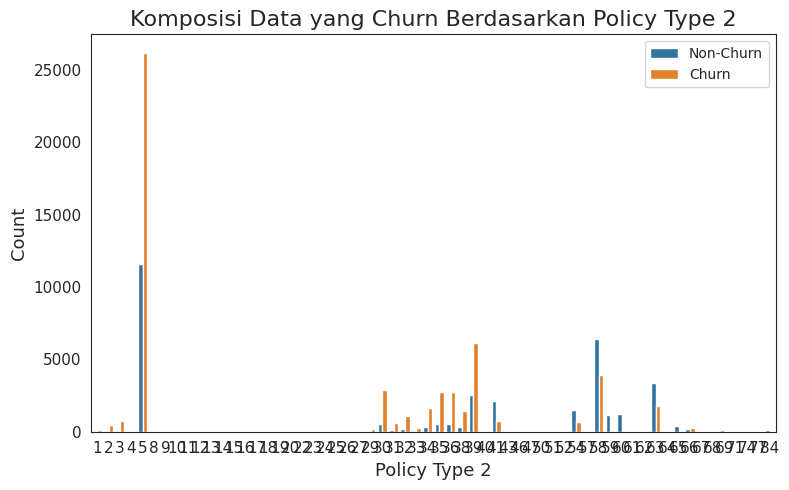

In [ ]:
# KOMPOSISI CHURN BERDASARKAN POLICY TYPE 2
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='POLICY TYPE 2', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Policy Type 2', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Policy Type 2", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN POLICY TYPE 2
fraud_by_policytype2 = df.groupby(['POLICY TYPE 2', 'CHURN']).size().reset_index(name='Count')
total_by_policytype2 = df.groupby('POLICY TYPE 2').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_policytype2 = fraud_by_policytype2.merge(total_by_policytype2, on='POLICY TYPE 2')

# PERSENTASE
merged_policytype2['Percentage'] = (merged_policytype2['Count'] / merged_policytype2['Total_Count']) * 100
merged_policytype2['Percentage'] = merged_policytype2['Percentage'].round(2).astype(str) + '%'
merged_policytype2['CHURN'] = merged_policytype2['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_policytype2)

     POLICY TYPE 2 CHURN  Count  Total_Count Percentage
0                1    No      6           96      6.25%
1                1   Yes     90           96     93.75%
2                2    No     28          513      5.46%
3                2   Yes    485          513     94.54%
4                3    No     24          734      3.27%
..             ...   ...    ...          ...        ...
100             71    No     24           24     100.0%
101             74    No      1            1     100.0%
102             77    No     41           96     42.71%
103             77   Yes     55           96     57.29%
104             84    No    124          124     100.0%

[105 rows x 5 columns]


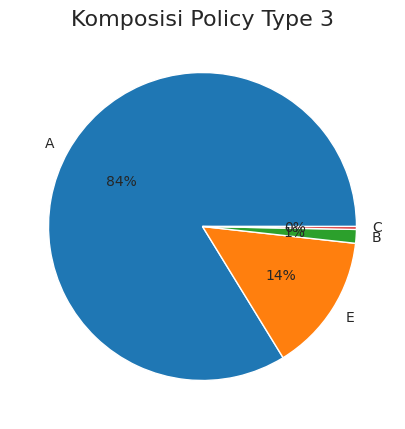

In [ ]:
# KOMPOSISI POLICY TYPE 3
plt.figure(figsize =(6,5))
plt.pie(df['POLICY TYPE 3'].value_counts(), labels=df['POLICY TYPE 3'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Policy Type 3', size = 16)
plt.show()

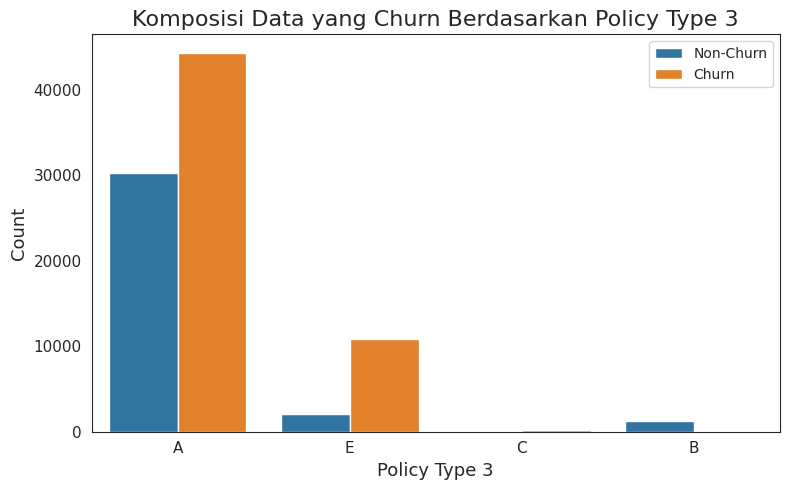

In [ ]:
# KOMPOSISI CHURN BERDASARKAN POLICY TYPE 3
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='POLICY TYPE 3', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Policy Type 3', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Policy Type 3", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN POLICY TYPE 3
fraud_by_policytype3 = df.groupby(['POLICY TYPE 3', 'CHURN']).size().reset_index(name='Count')
total_by_policytype3 = df.groupby('POLICY TYPE 3').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_policytype3 = fraud_by_policytype3.merge(total_by_policytype3, on='POLICY TYPE 3')

# PERSENTASE
merged_policytype3['Percentage'] = (merged_policytype3['Count'] / merged_policytype3['Total_Count']) * 100
merged_policytype3['Percentage'] = merged_policytype3['Percentage'].round(2).astype(str) + '%'
merged_policytype3['CHURN'] = merged_policytype3['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_policytype3)

  POLICY TYPE 3 CHURN  Count  Total_Count Percentage
0             A    No  30320        74623     40.63%
1             A   Yes  44303        74623     59.37%
2             B    No   1204         1284     93.77%
3             B   Yes     80         1284      6.23%
4             C    No    113          270     41.85%
5             C   Yes    157          270     58.15%
6             E    No   2053        12907     15.91%
7             E   Yes  10854        12907     84.09%


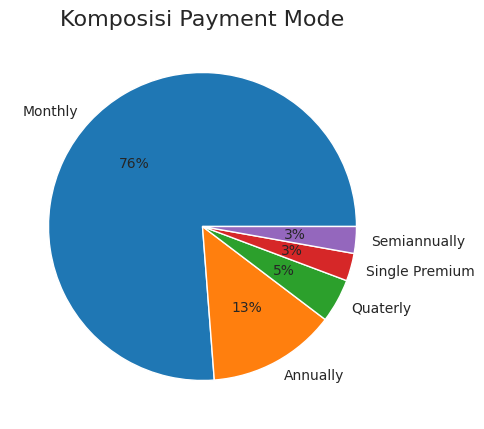

In [ ]:
# KOMPOSISI PAYMENT MODE
plt.figure(figsize =(6,5))
plt.pie(df['PAYMENT MODE'].value_counts(), labels=df['PAYMENT MODE'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Payment Mode', size = 16)
plt.show()

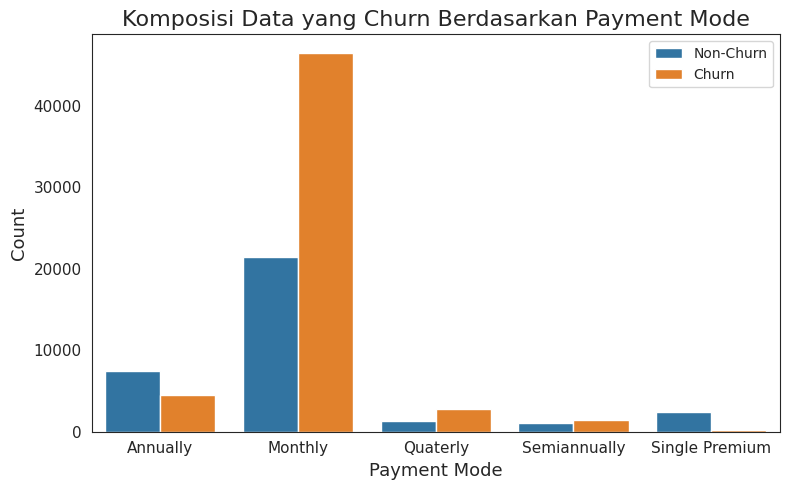

In [ ]:
# KOMPOSISI CHURN BERDASARKAN PAYMENT MODE
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='PAYMENT MODE', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Payment Mode', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Payment Mode", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN PAYMENT MODE
fraud_by_paymentmode = df.groupby(['PAYMENT MODE', 'CHURN']).size().reset_index(name='Count')
total_by_paymentmode = df.groupby('PAYMENT MODE').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_paymentmode = fraud_by_paymentmode.merge(total_by_paymentmode, on='PAYMENT MODE')

# PERSENTASE
merged_paymentmode['Percentage'] = (merged_paymentmode['Count'] / merged_paymentmode['Total_Count']) * 100
merged_paymentmode['Percentage'] = merged_paymentmode['Percentage'].round(2).astype(str) + '%'
merged_paymentmode['CHURN'] = merged_paymentmode['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_paymentmode)

     PAYMENT MODE CHURN  Count  Total_Count Percentage
0        Annually    No   7424        11987     61.93%
1        Annually   Yes   4563        11987     38.07%
2         Monthly    No  21478        67901     31.63%
3         Monthly   Yes  46423        67901     68.37%
4        Quaterly    No   1323         4103     32.24%
5        Quaterly   Yes   2780         4103     67.76%
6    Semiannually    No   1034         2500     41.36%
7    Semiannually   Yes   1466         2500     58.64%
8  Single Premium    No   2431         2593     93.75%
9  Single Premium   Yes    162         2593      6.25%


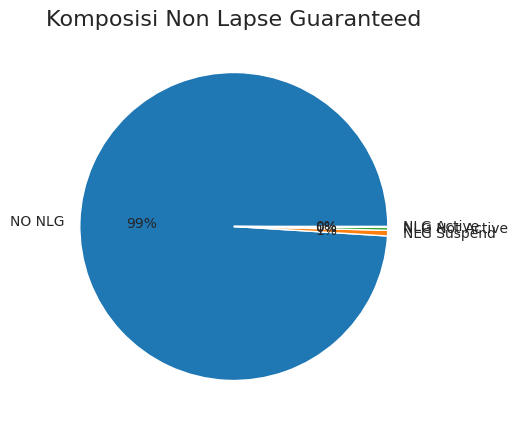

In [ ]:
# KOMPOSISI NON LAPSE GUARANTEED
plt.figure(figsize =(6,5))
plt.pie(df['NON LAPSE GUARANTEED'].value_counts(), labels=df['NON LAPSE GUARANTEED'].value_counts().index, autopct='%.0f%%')
plt.title('Komposisi Non Lapse Guaranteed', size = 16)
plt.show()

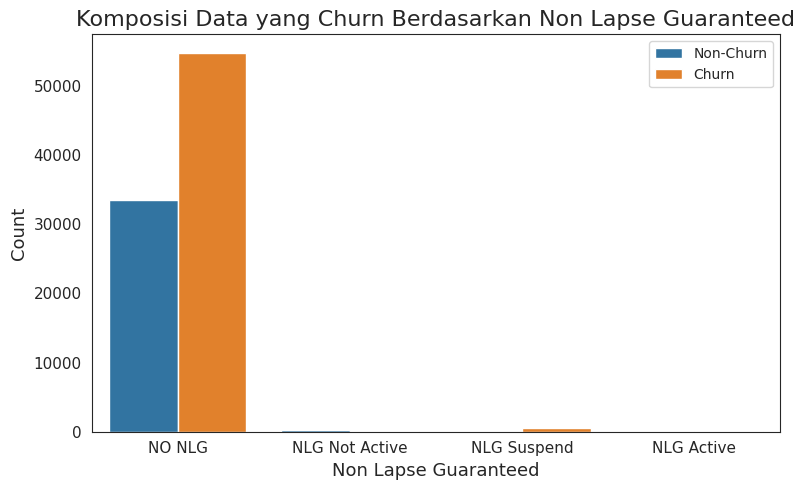

In [ ]:
# KOMPOSISI CHURN BERDASARKAN NON LAPSE GUARANTEED
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='NON LAPSE GUARANTEED', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Non Lapse Guaranteed', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Non Lapse Guaranteed", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN NON LAPSE GUARANTEED
fraud_by_nonlapseguaranteed = df.groupby(['NON LAPSE GUARANTEED', 'CHURN']).size().reset_index(name='Count')
total_by_nonlapseguaranteed = df.groupby('NON LAPSE GUARANTEED').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_nonlapseguaranteed = fraud_by_nonlapseguaranteed.merge(total_by_nonlapseguaranteed, on='NON LAPSE GUARANTEED')

# PERSENTASE
merged_nonlapseguaranteed['Percentage'] = (merged_nonlapseguaranteed['Count'] / merged_nonlapseguaranteed['Total_Count']) * 100
merged_nonlapseguaranteed['Percentage'] = merged_nonlapseguaranteed['Percentage'].round(2).astype(str) + '%'
merged_nonlapseguaranteed['CHURN'] = merged_nonlapseguaranteed['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_nonlapseguaranteed)

  NON LAPSE GUARANTEED CHURN  Count  Total_Count Percentage
0           NLG Active    No     18           82     21.95%
1           NLG Active   Yes     64           82     78.05%
2       NLG Not Active    No    178          269     66.17%
3       NLG Not Active   Yes     91          269     33.83%
4          NLG Suspend   Yes    524          524     100.0%
5               NO NLG    No  33494        88209     37.97%
6               NO NLG   Yes  54715        88209     62.03%


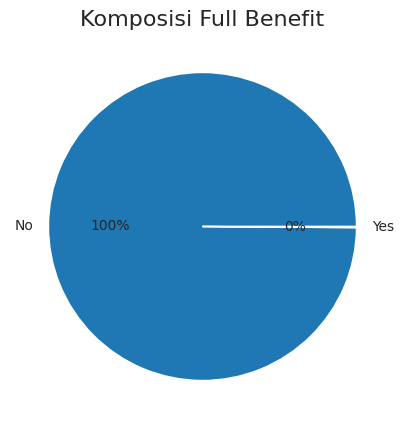

In [ ]:
# KOMPOSISI FULL BENEFIT
plt.figure(figsize =(6,5))
plt.pie(df['Full Benefit?'].value_counts(), labels=["No", "Yes"], autopct='%.0f%%')
plt.title('Komposisi Full Benefit', size = 16)
plt.show()

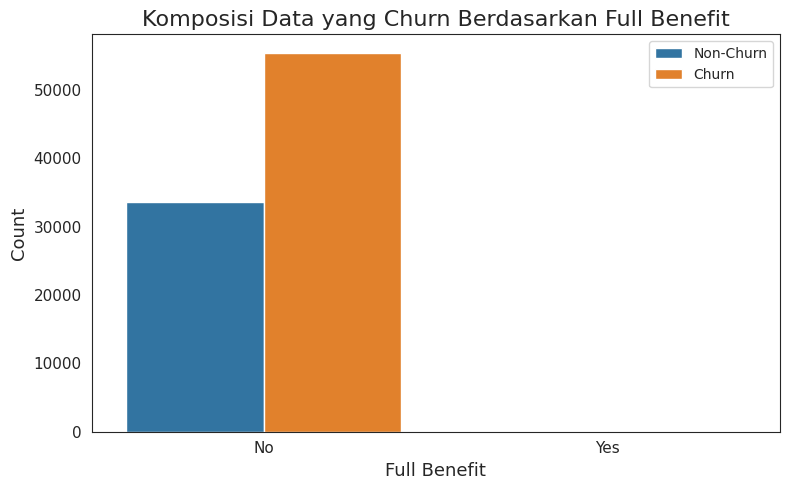

In [ ]:
# KOMPOSISI CHURN BERDASARKAN FULL BENEFIT
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Full Benefit?', hue='CHURN')

# X-AXIS
plt.xticks(size=11)
plt.xlabel('Full Benefit', size=13)
plt.xticks(rotation=0)  # MENGHINDARI OVERLAP
plt.xticks(['N', 'Y'], ["No", "Yes"] )

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Full Benefit", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'])

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH CHURN DAN NON-CHURN BERDASARKAN FULL BENEFIT
fraud_by_fullbenefit = df.groupby(['Full Benefit?', 'CHURN']).size().reset_index(name='Count')
total_by_fullbenefit = df.groupby('Full Benefit?').size().reset_index(name='Total_Count')  # Check the name here

# JOIN
merged_fullbenefit = fraud_by_fullbenefit.merge(total_by_fullbenefit, on='Full Benefit?')

# PERSENTASE
merged_fullbenefit['Percentage'] = (merged_fullbenefit['Count'] / merged_fullbenefit['Total_Count']) * 100
merged_fullbenefit['Percentage'] = merged_fullbenefit['Percentage'].round(2).astype(str) + '%'
merged_fullbenefit['CHURN'] = merged_fullbenefit['CHURN'].replace({0: 'No', 1: 'Yes'})
print(merged_fullbenefit)

  Full Benefit? CHURN  Count  Total_Count Percentage
0             N    No  33600        88975     37.76%
1             N   Yes  55375        88975     62.24%
2             Y    No     90          109     82.57%
3             Y   Yes     19          109     17.43%


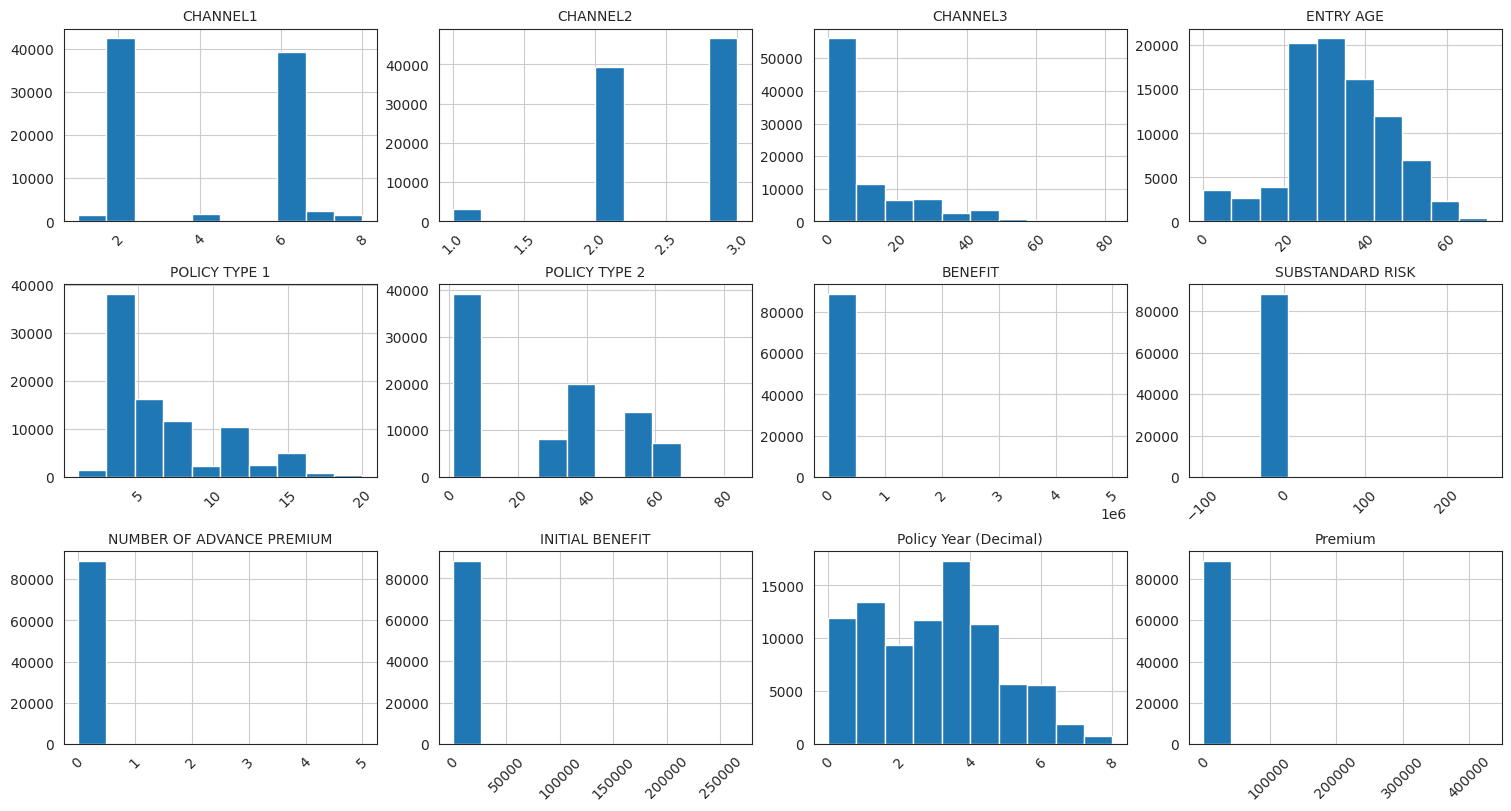

In [ ]:
fig, ax = plt.subplots(3, 4, figsize=(15, 8), constrained_layout=True)
for i in range(3):
    for j in range(4):
        index = 4 * i + j  # Menghitung indeks dengan benar
        if index < len(X_train_numeric.columns):
            df[X_train_numeric.columns[index]].hist(bins=10, ax=ax[i, j])
            ax[i, j].tick_params(axis='x', rotation=45)
            ax[i, j].set_title(X_train_numeric.columns[index], size=10)
        else:
            ax[i, j].axis('off')  # Matikan axis jika tidak ada data untuk subplot ini

plt.show()

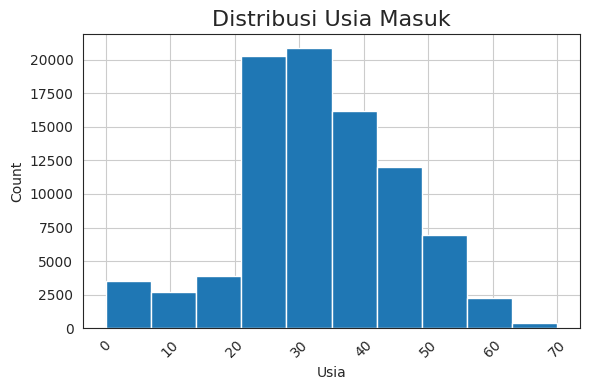

In [ ]:
# KOMPOSISI ENTRY AGE
plt.figure(figsize=(6, 4))
df['ENTRY AGE'].hist(bins=10)
plt.title('Distribusi Usia Masuk', size=16)
plt.xlabel('Usia')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

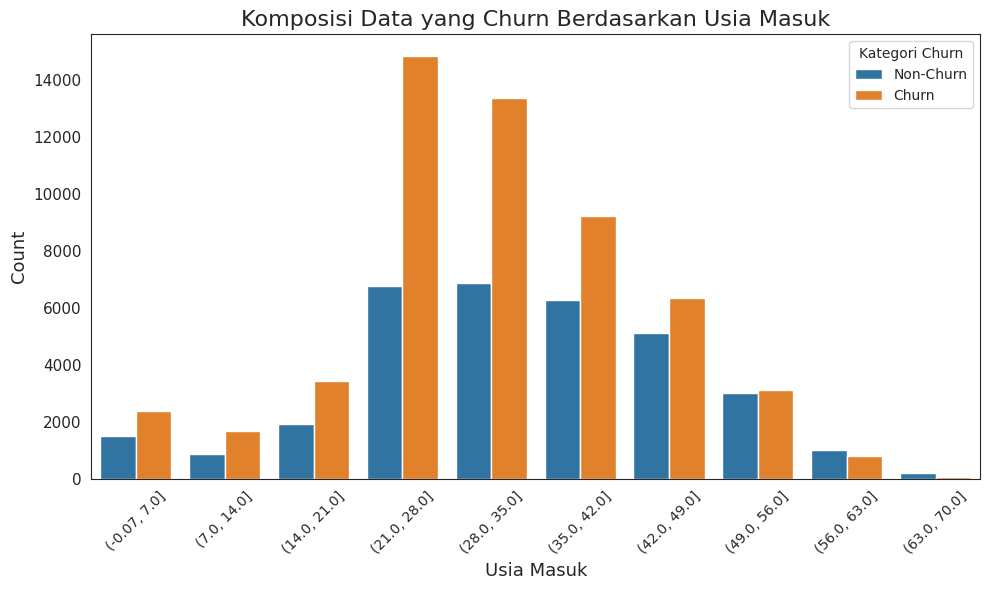

In [ ]:
# KOMPOSISI CHURN DAN NON-CHURN BERDASARKAN ENTRY AGE
# MEMBUAT 10 BIN UNTUK FITUR NUMERIK
df['ENTRY AGE'] = pd.cut(df['ENTRY AGE'], bins=10)

# MEMBUAT PLOT UNTUK FITUR age_of_driver
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ENTRY AGE', hue='CHURN')

# X-AXIS
plt.xticks(rotation=45, size=10)
plt.xlabel('Usia Masuk', size=13)

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Usia Masuk", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'], title='Kategori Churn')

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH FRAUD DAN NON-FRAUD BERDASARKAN USIA PENGEMUDI
fraud_by_entryage = df.groupby(['ENTRY AGE', 'CHURN'], observed=False).size().reset_index(name='Count')
total_by_entryage = df.groupby('ENTRY AGE', observed=False).size().reset_index(name='Total_Count')

# JOIN
merged_entryage = fraud_by_entryage.merge(total_by_entryage, on='ENTRY AGE')

# PERSENTASE
merged_entryage['Percentage'] = (merged_entryage['Count'] / merged_entryage['Total_Count']) * 100
merged_entryage['Percentage'] = merged_entryage['Percentage'].round(2).astype(str) + '%'

# MENGGANTI NILAI FRAUD DENGAN LABEL YANG LEBIH INFORMATIF
merged_entryage['CHURN'] = merged_entryage['CHURN'].replace({0: 'Non-Churn', 1: 'Churn'})

# MENAMPILKAN DATA
print(merged_entryage)

       ENTRY AGE      CHURN  Count  Total_Count Percentage
0   (-0.07, 7.0]  Non-Churn   1536         3944     38.95%
1   (-0.07, 7.0]      Churn   2408         3944     61.05%
2    (7.0, 14.0]  Non-Churn    899         2590     34.71%
3    (7.0, 14.0]      Churn   1691         2590     65.29%
4   (14.0, 21.0]  Non-Churn   1940         5384     36.03%
5   (14.0, 21.0]      Churn   3444         5384     63.97%
6   (21.0, 28.0]  Non-Churn   6772        21622     31.32%
7   (21.0, 28.0]      Churn  14850        21622     68.68%
8   (28.0, 35.0]  Non-Churn   6881        20234     34.01%
9   (28.0, 35.0]      Churn  13353        20234     65.99%
10  (35.0, 42.0]  Non-Churn   6276        15516     40.45%
11  (35.0, 42.0]      Churn   9240        15516     59.55%
12  (42.0, 49.0]  Non-Churn   5129        11496     44.62%
13  (42.0, 49.0]      Churn   6367        11496     55.38%
14  (49.0, 56.0]  Non-Churn   3026         6154     49.17%
15  (49.0, 56.0]      Churn   3128         6154     50.8

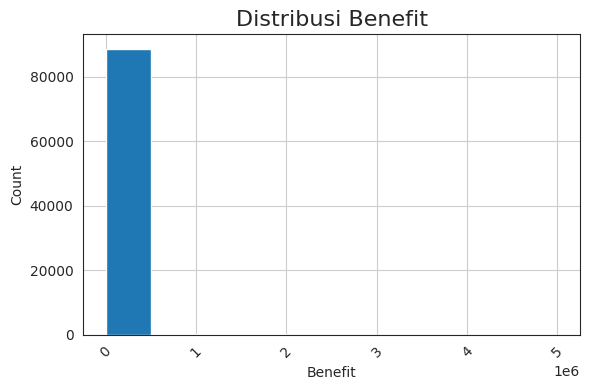

In [ ]:
# KOMPOSISI BENEFIT
plt.figure(figsize=(6, 4))
df['BENEFIT'].hist(bins=10)
plt.title('Distribusi Benefit', size=16)
plt.xlabel('Benefit')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

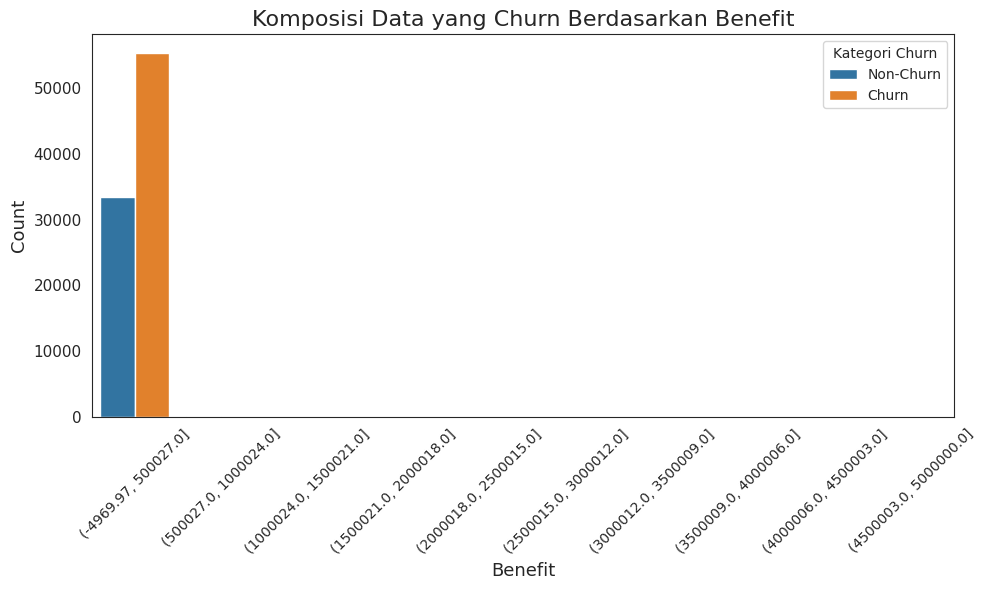

In [ ]:
# KOMPOSISI CHURN DAN NON-CHURN BERDASARKAN BENEFIT
# MEMBUAT 10 BIN UNTUK FITUR NUMERIK
df['BENEFIT'] = pd.cut(df['BENEFIT'], bins=10)

# MEMBUAT PLOT UNTUK FITUR age_of_driver
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='BENEFIT', hue='CHURN')

# X-AXIS
plt.xticks(rotation=45, size=10)
plt.xlabel('Benefit', size=13)

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Benefit", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'], title='Kategori Churn')

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH FRAUD DAN NON-FRAUD BERDASARKAN USIA PENGEMUDI
fraud_by_benefit = df.groupby(['BENEFIT', 'CHURN'], observed=False).size().reset_index(name='Count')
total_by_benefit = df.groupby('BENEFIT', observed=False).size().reset_index(name='Total_Count')

# JOIN
merged_benefit = fraud_by_benefit.merge(total_by_benefit, on='BENEFIT')

# PERSENTASE
merged_benefit['Percentage'] = (merged_benefit['Count'] / merged_benefit['Total_Count']) * 100
merged_benefit['Percentage'] = merged_benefit['Percentage'].round(2).astype(str) + '%'

# MENGGANTI NILAI FRAUD DENGAN LABEL YANG LEBIH INFORMATIF
merged_benefit['CHURN'] = merged_benefit['CHURN'].replace({0: 'Non-Churn', 1: 'Churn'})

# MENAMPILKAN DATA
print(merged_benefit)

                   BENEFIT      CHURN  Count  Total_Count Percentage
0     (-4969.97, 500027.0]  Non-Churn  33465        88796     37.69%
1     (-4969.97, 500027.0]      Churn  55331        88796     62.31%
2    (500027.0, 1000024.0]  Non-Churn    171          221     77.38%
3    (500027.0, 1000024.0]      Churn     50          221     22.62%
4   (1000024.0, 1500021.0]  Non-Churn     21           26     80.77%
5   (1000024.0, 1500021.0]      Churn      5           26     19.23%
6   (1500021.0, 2000018.0]  Non-Churn     25           30     83.33%
7   (1500021.0, 2000018.0]      Churn      5           30     16.67%
8   (2000018.0, 2500015.0]  Non-Churn      4            4     100.0%
9   (2000018.0, 2500015.0]      Churn      0            4       0.0%
10  (2500015.0, 3000012.0]  Non-Churn      1            2      50.0%
11  (2500015.0, 3000012.0]      Churn      1            2      50.0%
12  (3000012.0, 3500009.0]  Non-Churn      0            1       0.0%
13  (3000012.0, 3500009.0]      Ch

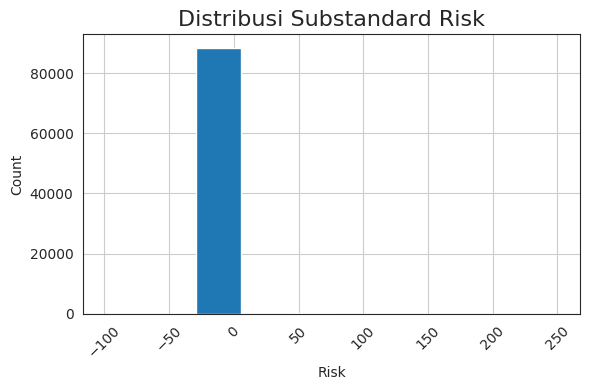

In [ ]:
# KOMPOSISI SUBSTANDARD RISK
plt.figure(figsize=(6, 4))
df['SUBSTANDARD RISK'].hist(bins=10)
plt.title('Distribusi Substandard Risk', size=16)
plt.xlabel('Risk')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

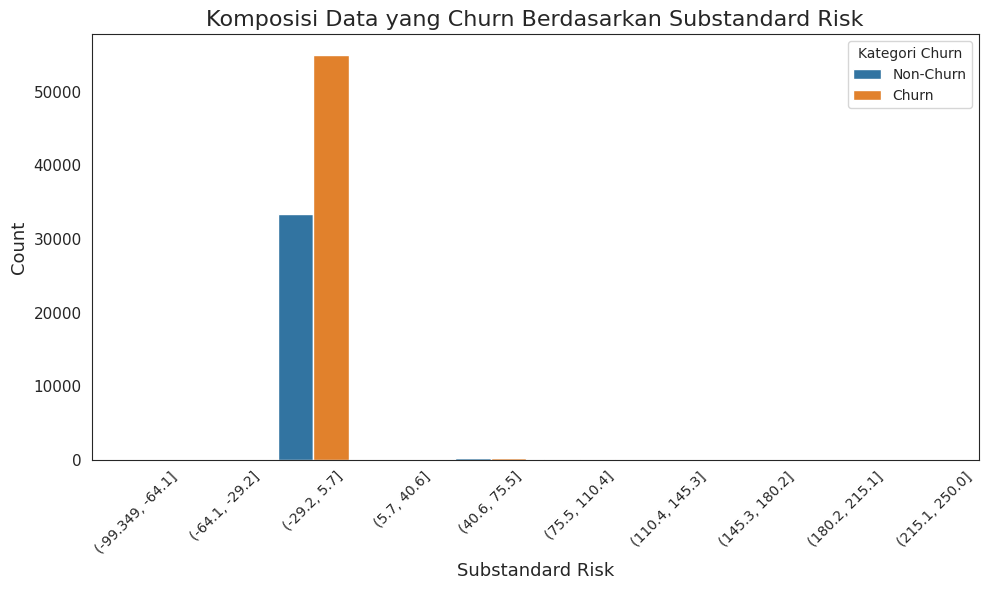

In [ ]:
# KOMPOSISI CHURN DAN NON-CHURN BERDASARKAN SUBSTANDARD RISK
# MEMBUAT 10 BIN UNTUK FITUR NUMERIK
df['SUBSTANDARD RISK'] = pd.cut(df['SUBSTANDARD RISK'], bins=10)

# MEMBUAT PLOT UNTUK FITUR age_of_driver
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='SUBSTANDARD RISK', hue='CHURN')

# X-AXIS
plt.xticks(rotation=45, size=10)
plt.xlabel('Substandard Risk', size=13)

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Substandard Risk", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'], title='Kategori Churn')

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH FRAUD DAN NON-FRAUD BERDASARKAN SUBSTANDARD RISK
fraud_by_substandardrisk = df.groupby(['SUBSTANDARD RISK', 'CHURN'], observed=False).size().reset_index(name='Count')
total_by_substandardrisk = df.groupby('SUBSTANDARD RISK', observed=False).size().reset_index(name='Total_Count')

# JOIN
merged_substandardrisk = fraud_by_substandardrisk.merge(total_by_substandardrisk, on='SUBSTANDARD RISK')

# PERSENTASE
merged_substandardrisk['Percentage'] = (merged_substandardrisk['Count'] / merged_substandardrisk['Total_Count']) * 100
merged_substandardrisk['Percentage'] = merged_substandardrisk['Percentage'].round(2).astype(str) + '%'

# MENGGANTI NILAI FRAUD DENGAN LABEL YANG LEBIH INFORMATIF
merged_substandardrisk['CHURN'] = merged_substandardrisk['CHURN'].replace({0: 'Non-Churn', 1: 'Churn'})

# MENAMPILKAN DATA
print(merged_substandardrisk)

    SUBSTANDARD RISK      CHURN  Count  Total_Count Percentage
0   (-99.349, -64.1]  Non-Churn      2            2     100.0%
1   (-99.349, -64.1]      Churn      0            2       0.0%
2     (-64.1, -29.2]  Non-Churn      6           21     28.57%
3     (-64.1, -29.2]      Churn     15           21     71.43%
4       (-29.2, 5.7]  Non-Churn  33355        88419     37.72%
5       (-29.2, 5.7]      Churn  55064        88419     62.28%
6        (5.7, 40.6]  Non-Churn     27           44     61.36%
7        (5.7, 40.6]      Churn     17           44     38.64%
8       (40.6, 75.5]  Non-Churn    187          380     49.21%
9       (40.6, 75.5]      Churn    193          380     50.79%
10     (75.5, 110.4]  Non-Churn     65          146     44.52%
11     (75.5, 110.4]      Churn     81          146     55.48%
12    (110.4, 145.3]  Non-Churn     11           12     91.67%
13    (110.4, 145.3]      Churn      1           12      8.33%
14    (145.3, 180.2]  Non-Churn     30           45    

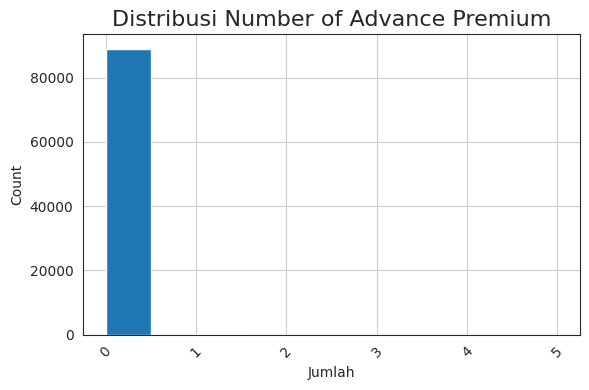

In [ ]:
# KOMPOSISI NUMBER OF ADVANCE PREMIUM
plt.figure(figsize=(6, 4))
df['NUMBER OF ADVANCE PREMIUM'].hist(bins=10)
plt.title('Distribusi Number of Advance Premium', size=16)
plt.xlabel('Jumlah')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

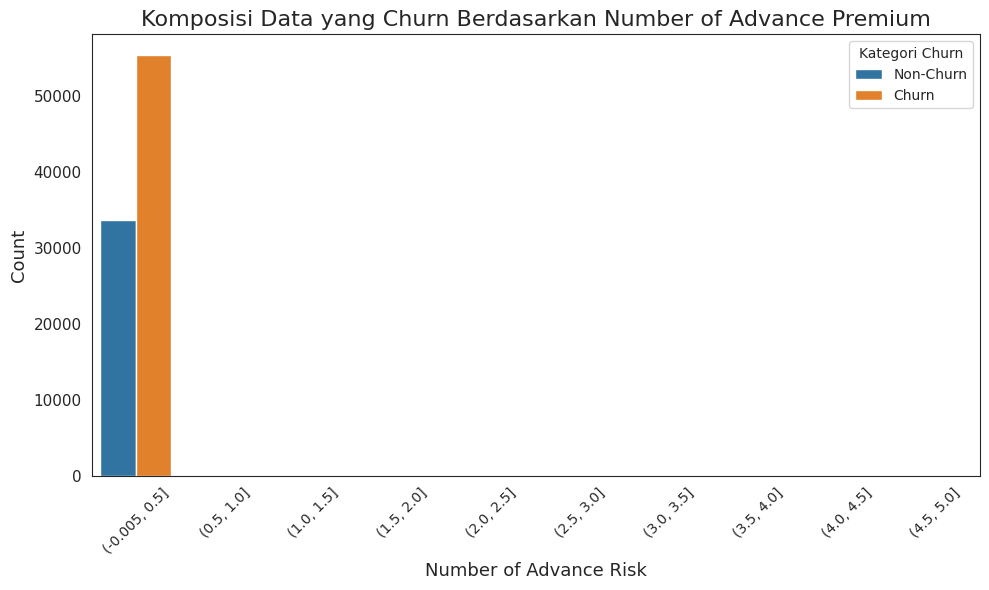

In [ ]:
# KOMPOSISI CHURN DAN NON-CHURN BERDASARKAN NUMBER OF ADVANCE PREMIUM
# MEMBUAT 10 BIN UNTUK FITUR NUMERIK
df['NUMBER OF ADVANCE PREMIUM'] = pd.cut(df['NUMBER OF ADVANCE PREMIUM'], bins=10)

# MEMBUAT PLOT UNTUK FITUR age_of_driver
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='NUMBER OF ADVANCE PREMIUM', hue='CHURN')

# X-AXIS
plt.xticks(rotation=45, size=10)
plt.xlabel('Number of Advance Risk', size=13)

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Number of Advance Premium", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'], title='Kategori Churn')

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH FRAUD DAN NON-FRAUD BERDASARKAN NUMBER OF ADVANCE PREMIUM
fraud_by_numberofadvancepremium = df.groupby(['NUMBER OF ADVANCE PREMIUM', 'CHURN'], observed=False).size().reset_index(name='Count')
total_by_numberofadvancepremium = df.groupby('NUMBER OF ADVANCE PREMIUM', observed=False).size().reset_index(name='Total_Count')

# JOIN
merged_numberofadvancepremium = fraud_by_numberofadvancepremium.merge(total_by_numberofadvancepremium, on='NUMBER OF ADVANCE PREMIUM')

# PERSENTASE
merged_numberofadvancepremium['Percentage'] = (merged_numberofadvancepremium['Count'] / merged_numberofadvancepremium['Total_Count']) * 100
merged_numberofadvancepremium['Percentage'] = merged_numberofadvancepremium['Percentage'].round(2).astype(str) + '%'

# MENGGANTI NILAI FRAUD DENGAN LABEL YANG LEBIH INFORMATIF
merged_numberofadvancepremium['CHURN'] = merged_numberofadvancepremium['CHURN'].replace({0: 'Non-Churn', 1: 'Churn'})

# MENAMPILKAN DATA
print(merged_numberofadvancepremium)

   NUMBER OF ADVANCE PREMIUM      CHURN  Count  Total_Count Percentage
0              (-0.005, 0.5]  Non-Churn  33662        89056      37.8%
1              (-0.005, 0.5]      Churn  55394        89056      62.2%
2                 (0.5, 1.0]  Non-Churn     25           25     100.0%
3                 (0.5, 1.0]      Churn      0           25       0.0%
4                 (1.0, 1.5]  Non-Churn      0            0       nan%
5                 (1.0, 1.5]      Churn      0            0       nan%
6                 (1.5, 2.0]  Non-Churn      0            0       nan%
7                 (1.5, 2.0]      Churn      0            0       nan%
8                 (2.0, 2.5]  Non-Churn      0            0       nan%
9                 (2.0, 2.5]      Churn      0            0       nan%
10                (2.5, 3.0]  Non-Churn      1            1     100.0%
11                (2.5, 3.0]      Churn      0            1       0.0%
12                (3.0, 3.5]  Non-Churn      0            0       nan%
13    

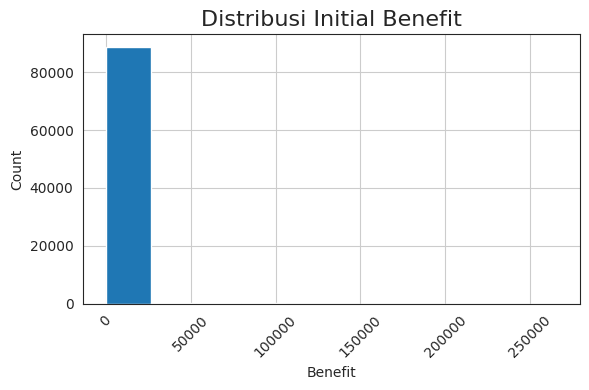

In [ ]:
# KOMPOSISI INITIAL BENEFIT
plt.figure(figsize=(6, 4))
df['INITIAL BENEFIT'].hist(bins=10)
plt.title('Distribusi Initial Benefit', size=16)
plt.xlabel('Benefit')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

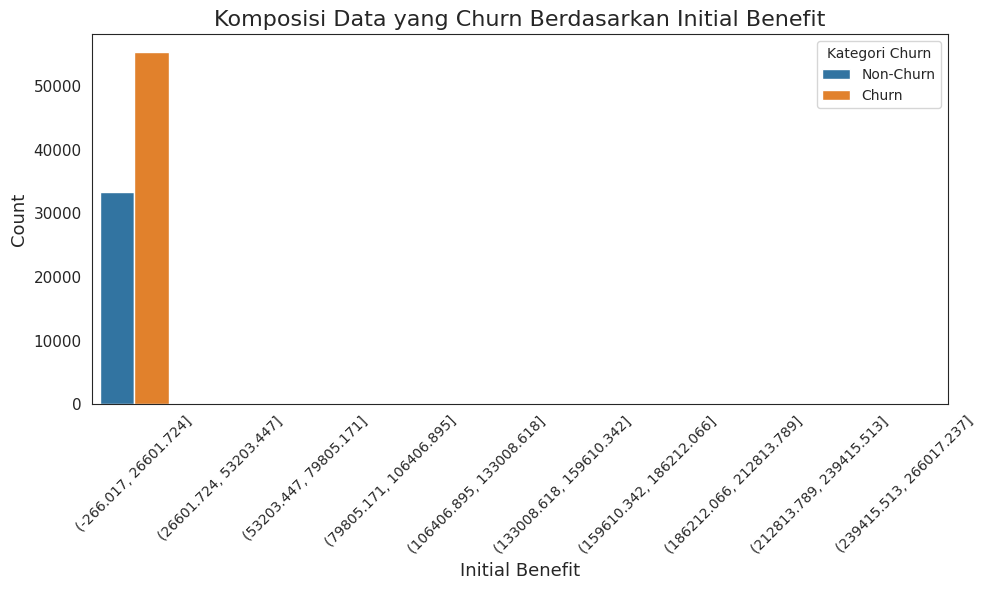

In [ ]:
# KOMPOSISI CHURN DAN NON-CHURN BERDASARKAN INITIAL BENEFIT
# MEMBUAT 10 BIN UNTUK FITUR NUMERIK
df['INITIAL BENEFIT'] = pd.cut(df['INITIAL BENEFIT'], bins=10)

# MEMBUAT PLOT UNTUK FITUR age_of_driver
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='INITIAL BENEFIT', hue='CHURN')

# X-AXIS
plt.xticks(rotation=45, size=10)
plt.xlabel('Initial Benefit', size=13)

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Initial Benefit", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'], title='Kategori Churn')

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH FRAUD DAN NON-FRAUD BERDASARKAN NUMBER OF INITIAL BENEFIT
fraud_by_initialbenefit = df.groupby(['INITIAL BENEFIT', 'CHURN'], observed=False).size().reset_index(name='Count')
total_by_initialbenefit = df.groupby('INITIAL BENEFIT', observed=False).size().reset_index(name='Total_Count')

# JOIN
merged_initialbenefit = fraud_by_initialbenefit.merge(total_by_initialbenefit, on='INITIAL BENEFIT')

# PERSENTASE
merged_initialbenefit['Percentage'] = (merged_initialbenefit['Count'] / merged_initialbenefit['Total_Count']) * 100
merged_initialbenefit['Percentage'] = merged_initialbenefit['Percentage'].round(2).astype(str) + '%'

# MENGGANTI NILAI FRAUD DENGAN LABEL YANG LEBIH INFORMATIF
merged_initialbenefit['CHURN'] = merged_initialbenefit['CHURN'].replace({0: 'Non-Churn', 1: 'Churn'})

# MENAMPILKAN DATA
print(merged_initialbenefit)

             INITIAL BENEFIT      CHURN  Count  Total_Count Percentage
0      (-266.017, 26601.724]  Non-Churn  33300        88678     37.55%
1      (-266.017, 26601.724]      Churn  55378        88678     62.45%
2     (26601.724, 53203.447]  Non-Churn    246          255     96.47%
3     (26601.724, 53203.447]      Churn      9          255      3.53%
4     (53203.447, 79805.171]  Non-Churn     96          100      96.0%
5     (53203.447, 79805.171]      Churn      4          100       4.0%
6    (79805.171, 106406.895]  Non-Churn     40           41     97.56%
7    (79805.171, 106406.895]      Churn      1           41      2.44%
8   (106406.895, 133008.618]  Non-Churn      3            3     100.0%
9   (106406.895, 133008.618]      Churn      0            3       0.0%
10  (133008.618, 159610.342]  Non-Churn      3            4      75.0%
11  (133008.618, 159610.342]      Churn      1            4      25.0%
12  (159610.342, 186212.066]  Non-Churn      1            1     100.0%
13  (1

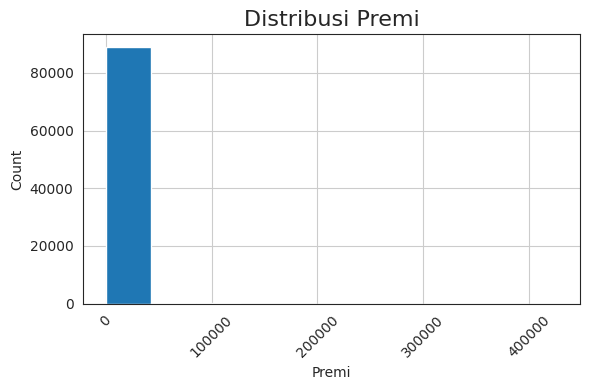

In [ ]:
# KOMPOSISI PREMIUM
plt.figure(figsize=(6, 4))
df['Premium'].hist(bins=10)
plt.title('Distribusi Premi', size=16)
plt.xlabel('Premi')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

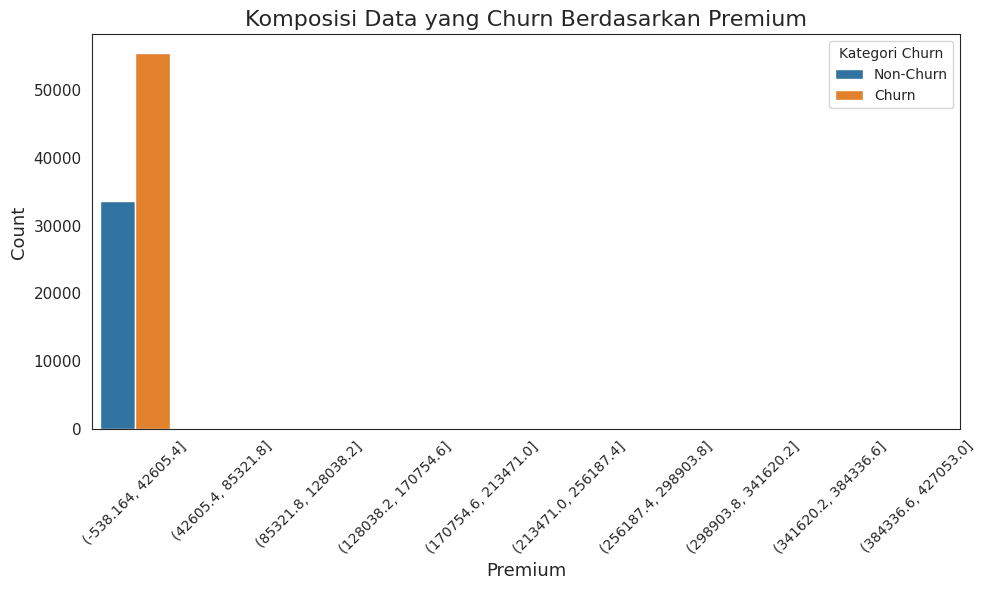

In [ ]:
# KOMPOSISI CHURN DAN NON-CHURN BERDASARKAN PREMIUM
# MEMBUAT 10 BIN UNTUK FITUR NUMERIK
df['Premium'] = pd.cut(df['Premium'], bins=10)

# MEMBUAT PLOT UNTUK FITUR age_of_driver
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Premium', hue='CHURN')

# X-AXIS
plt.xticks(rotation=45, size=10)
plt.xlabel('Premium', size=13)

# Y-AXIS
plt.yticks(size=11)
plt.ylabel('Count', size=13)
plt.title("Komposisi Data yang Churn Berdasarkan Premium", size=16)

# LEGEND
plt.legend(labels=['Non-Churn', 'Churn'], title='Kategori Churn')

# MENYESUAIKAN GRAFIK
plt.tight_layout()

# PRINT GRAFIK
plt.show()

In [ ]:
# JUMLAH FRAUD DAN NON-FRAUD BERDASARKAN NUMBER OF PREMIUM
fraud_by_premium = df.groupby(['Premium', 'CHURN'], observed=False).size().reset_index(name='Count')
total_by_premium = df.groupby('Premium', observed=False).size().reset_index(name='Total_Count')

# JOIN
merged_premium = fraud_by_premium.merge(total_by_premium, on='Premium')

# PERSENTASE
merged_premium['Percentage'] = (merged_premium['Count'] / merged_premium['Total_Count']) * 100
merged_premium['Percentage'] = merged_premium['Percentage'].round(2).astype(str) + '%'

# MENGGANTI NILAI FRAUD DENGAN LABEL YANG LEBIH INFORMATIF
merged_premium['CHURN'] = merged_premium['CHURN'].replace({0: 'Non-Churn', 1: 'Churn'})

# MENAMPILKAN DATA
print(merged_premium)

                 Premium      CHURN  Count  Total_Count Percentage
0    (-538.164, 42605.4]  Non-Churn  33546        88903     37.73%
1    (-538.164, 42605.4]      Churn  55357        88903     62.27%
2     (42605.4, 85321.8]  Non-Churn     92          121     76.03%
3     (42605.4, 85321.8]      Churn     29          121     23.97%
4    (85321.8, 128038.2]  Non-Churn     34           41     82.93%
5    (85321.8, 128038.2]      Churn      7           41     17.07%
6   (128038.2, 170754.6]  Non-Churn      7            7     100.0%
7   (128038.2, 170754.6]      Churn      0            7       0.0%
8   (170754.6, 213471.0]  Non-Churn      5            5     100.0%
9   (170754.6, 213471.0]      Churn      0            5       0.0%
10  (213471.0, 256187.4]  Non-Churn      0            0       nan%
11  (213471.0, 256187.4]      Churn      0            0       nan%
12  (256187.4, 298903.8]  Non-Churn      0            0       nan%
13  (256187.4, 298903.8]      Churn      0            0       

# Encoding dan Scaling

In [ ]:
num_cols = X_train[all_features].select_dtypes(include=['number']).columns
cat_cols = X_train[all_features].select_dtypes(include=['object']).columns

# transformers
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# preprocessor
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [ ]:
### Transformers for numerical data
numerical_transformer = Pipeline(steps=[('Scaler', MinMaxScaler())])
### Transformers for categorical data
categorical_transformer = Pipeline(steps=[('Encoder',
OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
preprocessing = ColumnTransformer(transformers=[('Numerical', numerical_transformer, num_cols),
('Categorical', categorical_transformer, cat_cols)], remainder='passthrough')

In [ ]:
preprocessing

ColumnTransformer(remainder='passthrough',
                  transformers=[('Numerical',
                                 Pipeline(steps=[('Scaler', MinMaxScaler())]),
                                 Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'BENEFIT', 'SUBSTANDARD RISK',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'Policy Year (Decimal)',
       'Premium'],
      dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('Encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['SEX', 'POLICY TYPE 3', 'PAYMENT MODE', 'NON LAPSE GUARANTEED',
       'Full Benefit?', 'Issue Date'],
      dtype='object'))])

# Decision Tree

In [ ]:
# Grid Parameter
param_dt = {
    'max_depth': np.arange(12, 17),
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'min_samples_split': [244, 245, 246, 247, 248]
}


In [ ]:
# Create pipeline
dt_grid = GridSearchCV(DecisionTreeClassifier(criterion='entropy'), n_jobs=-1,
param_grid=param_dt, scoring='roc_auc',cv=5)

dt_pipeline = Pipeline([
('preprocessor', preprocessor),
('grid_search', dt_grid)
])

In [ ]:
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'BENEFIT', 'SUBSTANDARD RISK',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'Policy Year (Decimal)',
       'Premium'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['SEX', 'POLICY TYPE 3', 'PAYMENT MODE', 'NON LAPSE GUARANTEED',
       'Full Benefit?', 'Issue Date'],
      dtype='object'))])),
                ('grid_search',
                 GridSearchCV(cv=5,
                              estimator=DecisionTreeClassifier(criterion='entropy'),
                              n_jobs=-1,
                              param_grid={'max_depth': array([12, 13, 14, 15, 16]),
                                          'min_samples_leaf': [1, 2, 3, 4, 5],
                                          'min_samples_split': [244, 245, 246,
                                                                247, 248]},
                              scoring='roc_auc'))])

In [ ]:
# Mengakses hyperparameter terbaik dari GridSearchCV
best_params = dt_pipeline.named_steps['grid_search'].best_params_
print("Best hyperparameters:", best_params)

Best hyperparameters: {'max_depth': np.int64(14), 'min_samples_leaf': 3, 'min_samples_split': 245}


In [ ]:
pd.DataFrame(dt_pipeline.named_steps['grid_search'].cv_results_).sort_values("rank_test_score"
, ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
61,2.598493,0.400011,0.014154,0.003927,14,3,245,"{'max_depth': 14, 'min_samples_leaf': 3, 'min_...",0.797446,0.800356,0.802036,0.799103,0.803203,0.800429,0.002046,1
62,1.793967,0.064135,0.010741,0.000690,14,3,246,"{'max_depth': 14, 'min_samples_leaf': 3, 'min_...",0.797411,0.800356,0.802036,0.799103,0.803188,0.800419,0.002053,2
64,2.560656,0.342630,0.013952,0.005017,14,3,248,"{'max_depth': 14, 'min_samples_leaf': 3, 'min_...",0.797415,0.800206,0.802171,0.799068,0.803188,0.800410,0.002080,3
60,1.792060,0.079084,0.010936,0.001295,14,3,244,"{'max_depth': 14, 'min_samples_leaf': 3, 'min_...",0.797319,0.800526,0.802036,0.798992,0.803166,0.800408,0.002089,4
71,1.820362,0.055747,0.010382,0.000186,14,5,245,"{'max_depth': 14, 'min_samples_leaf': 5, 'min_...",0.797789,0.799933,0.802287,0.798092,0.803658,0.800352,0.002303,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,2.535988,0.577293,0.010624,0.000555,16,1,244,"{'max_depth': 16, 'min_samples_leaf': 1, 'min_...",0.797276,0.798709,0.800910,0.797756,0.802982,0.799527,0.002132,121
117,2.553929,0.491170,0.011994,0.002538,16,4,246,"{'max_depth': 16, 'min_samples_leaf': 4, 'min_...",0.796823,0.799291,0.801052,0.798141,0.802305,0.799522,0.001966,122
119,2.888696,0.408859,0.012742,0.002991,16,4,248,"{'max_depth': 16, 'min_samples_leaf': 4, 'min_...",0.796823,0.799194,0.801183,0.798097,0.802282,0.799516,0.001990,123
107,2.953877,0.569489,0.012198,0.002886,16,2,246,"{'max_depth': 16, 'min_samples_leaf': 2, 'min_...",0.796626,0.798640,0.801281,0.797918,0.803068,0.799507,0.002341,124


In [ ]:
joblib.dump(dt_pipeline, 'model_dt5')

['model_dt5']

In [ ]:
model_dt = DecisionTreeClassifier(criterion='entropy',**dt_pipeline.named_steps['grid_search'].best_params_)

dt_pipelines = Pipeline([('preprocessor', preprocessor),
('model', model_dt)])


In [ ]:
roc_auc = []
precision = []
recall = []
f1 = []

In [ ]:
results = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "Specificity": [],
    "F1 Score": [],
    "ROC-AUC": []
}

for i in range(5):
  print(f"\n========== ITERATION {i+1} ==========")

  dt_pipelines.fit(X_train, y_train)

  # Prediksi probabilitas
  y_prob = dt_pipelines.predict_proba(X_test)[:, 1]

  # Konversi probabilitas ke kelas
  y_pred = dt_pipelines.predict(X_test)

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = cm.ravel()

  # Calculate Metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='binary')
  recall = recall_score(y_test, y_pred, average='binary')
  specificity = tn / (tn + fp)
  f1 = f1_score(y_test, y_pred, average='binary')

  # Calculate ROC AUC
  roc_auc = roc_auc_score(y_test, y_prob)

  print(f"Accuracy = {accuracy}")
  print(f"Precision = {precision}")
  print(f"Recall = {recall}")
  print(f"Specificity = {specificity}")
  print(f"F1 Score = {f1}")
  print(f"ROC_AUC = {roc_auc}")

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

  print("\nConfusion Matrix:")
  print(cm)
  print(f"\nTrue Negative (TN): {tn}")
  print(f"False Positive (FP): {fp}")
  print(f"False Negative (FN): {fn}")
  print(f"True Positive (TP): {tp}")
  print(" ")

  # Simpan ke list
  results["Accuracy"].append(accuracy)
  results["Precision"].append(precision)
  results["Recall"].append(recall)
  results["Specificity"].append(specificity)
  results["F1 Score"].append(f1)
  results["ROC-AUC"].append(roc_auc)

df = pd.DataFrame({
    "Evaluation": list(results.keys()),
    "1st Iteration": [results[m][0] for m in results],
    "2nd Iteration": [results[m][1] for m in results],
    "3rd Iteration": [results[m][2] for m in results],
    "4th Iteration": [results[m][3] for m in results],
    "5th Iteration": [results[m][4] for m in results],
    "Average": [np.mean(results[m]) for m in results],
    "Standard Deviation": [np.std(results[m], ddof=0) for m in results]
})
print(df)



========== ITERATION 1 ==========
Accuracy = 0.7603412471235337
Precision = 0.7589360567029952
Recall = 0.8999548124717578
Specificity = 0.5315462085308057
F1 Score = 0.8234515835607377
ROC_AUC = 0.800521148994631

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.53      0.63      6752
           1       0.76      0.90      0.82     11065

    accuracy                           0.76     17817
   macro avg       0.76      0.72      0.73     17817
weighted avg       0.76      0.76      0.75     17817


Confusion Matrix:
[[3589 3163]
 [1107 9958]]

True Negative (TN): 3589
False Positive (FP): 3163
False Negative (FN): 1107
True Positive (TP): 9958
 

========== ITERATION 2 ==========
Accuracy = 0.7603412471235337
Precision = 0.7589360567029952
Recall = 0.8999548124717578
Specificity = 0.5315462085308057
F1 Score = 0.8234515835607377
ROC_AUC = 0.800521148994631

Classification Report:
              precision    recall  f1-score 

# Random Forest

In [ ]:
param_rf = {'max_depth': np.arange(39, 42),
'min_samples_leaf': (1,2),
'min_samples_split': (20,25,30)}

In [ ]:
# Create pipelines with SMOTE for each model (nested GridSearchCV)
rf_grid = GridSearchCV(RandomForestClassifier(n_estimators=250,
criterion='entropy',
n_jobs=-1),
param_grid=param_rf, scoring='roc_auc',cv=5)

rf_pipeline = Pipeline([
('preprocessor', preprocessor),
('grid_search', rf_grid)
])

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'BENEFIT', 'SUBSTANDARD RISK',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'Policy Year (Decimal)',
       'Premium'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['SEX', 'POLICY TYPE 3', 'PAYMENT MODE', 'NON LAPSE GUARANTEED',
       'Full Benefit?', 'Issue Date'],
      dtype='object'))])),
                ('grid_search',
                 GridSearchCV(cv=5,
                              estimator=RandomForestClassifier(criterion='entropy',
                                                               n_estimators=250,
                                                               n_jobs=-1),
                              param_grid={'max_depth': array([39, 40, 41]),
                                          'min_samples_leaf': (1, 2),
                                          'min_samples_split': (20, 25, 30)},
                              scoring='roc_auc'))])

In [ ]:
# Mengakses hyperparameter terbaik dari GridSearchCV
best_params = rf_pipeline.named_steps['grid_search'].best_params_
print("Best hyperparameters:", best_params)

Best hyperparameters: {'max_depth': np.int64(39), 'min_samples_leaf': 1, 'min_samples_split': 30}


In [ ]:
pd.DataFrame(rf_pipeline.named_steps['grid_search'].cv_results_).sort_values("rank_test_score"
, ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,75.882492,0.109294,0.697500,0.149545,39,1,30,"{'max_depth': 39, 'min_samples_leaf': 1, 'min_...",0.807399,0.812980,0.817870,0.813898,0.815439,0.813517,0.003479,1
1,80.856646,1.126678,0.755725,0.125874,39,1,25,"{'max_depth': 39, 'min_samples_leaf': 1, 'min_...",0.807046,0.813263,0.817304,0.814167,0.815502,0.813456,0.003482,2
8,77.425778,0.444952,0.797427,0.183199,40,1,30,"{'max_depth': 40, 'min_samples_leaf': 1, 'min_...",0.807111,0.813090,0.817055,0.814127,0.815332,0.813343,0.003384,3
5,67.263035,1.169224,0.596988,0.077490,39,2,30,"{'max_depth': 39, 'min_samples_leaf': 2, 'min_...",0.806993,0.813248,0.817225,0.813473,0.815504,0.813289,0.003466,4
17,69.013393,1.181225,0.649548,0.153892,41,2,30,"{'max_depth': 41, 'min_samples_leaf': 2, 'min_...",0.806873,0.813244,0.816971,0.813215,0.815831,0.813227,0.003498,5
4,70.071564,0.898304,0.648996,0.129672,39,2,25,"{'max_depth': 39, 'min_samples_leaf': 2, 'min_...",0.807319,0.812584,0.817035,0.813094,0.816099,0.813226,0.003408,6
16,71.218981,0.530252,0.661257,0.166422,41,2,25,"{'max_depth': 41, 'min_samples_leaf': 2, 'min_...",0.807331,0.812876,0.817254,0.813538,0.815108,0.813221,0.003309,7
7,79.982179,0.525519,0.830021,0.236612,40,1,25,"{'max_depth': 40, 'min_samples_leaf': 1, 'min_...",0.807292,0.812457,0.817412,0.813522,0.815290,0.813195,0.003396,8
9,73.590231,0.795787,0.767237,0.223552,40,2,20,"{'max_depth': 40, 'min_samples_leaf': 2, 'min_...",0.806792,0.812850,0.816709,0.813427,0.815884,0.813132,0.003485,9
13,82.611122,2.014884,0.694098,0.056407,41,1,25,"{'max_depth': 41, 'min_samples_leaf': 1, 'min_...",0.807636,0.812585,0.816983,0.813267,0.815099,0.813114,0.003137,10


In [ ]:
joblib.dump(rf_pipeline, 'model_rf7.h5')

['model_rf7.h5']

In [ ]:
model_rf = RandomForestClassifier(n_estimators=250,criterion='entropy',**rf_pipeline.named_steps['grid_search'].best_params_)

rf_pipelines = Pipeline([('preprocessor', preprocessor),
('model', model_rf)])

In [ ]:
roc_auc = []
precision = []
recall = []
f1 = []

In [ ]:
results = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "Specificity": [],
    "F1 Score": [],
    "ROC-AUC": []
}

for i in range(5):
  print(f"\n========== ITERATION {i+1} ==========")

  rf_pipelines.fit(X_train, y_train)

  # Prediksi probabilitas
  y_prob = rf_pipelines.predict_proba(X_test)[:, 1]

  # Konversi probabilitas ke kelas
  y_pred = rf_pipelines.predict(X_test)

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = cm.ravel()

  # Calculate Metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='binary')
  recall = recall_score(y_test, y_pred, average='binary')
  specificity = tn / (tn + fp)
  f1 = f1_score(y_test, y_pred, average='binary')

  # Calculate ROC AUC
  roc_auc = roc_auc_score(y_test, y_prob)

  print(f"Accuracy = {accuracy}")
  print(f"Precision = {precision}")
  print(f"Recall = {recall}")
  print(f"Specificity = {specificity}")
  print(f"F1 Score = {f1}")
  print(f"ROC_AUC = {roc_auc}")

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

  print("\nConfusion Matrix:")
  print(cm)
  print(f"\nTrue Negative (TN): {tn}")
  print(f"False Positive (FP): {fp}")
  print(f"False Negative (FN): {fn}")
  print(f"True Positive (TP): {tp}")
  print(" ")

  # Simpan ke list
  results["Accuracy"].append(accuracy)
  results["Precision"].append(precision)
  results["Recall"].append(recall)
  results["Specificity"].append(specificity)
  results["F1 Score"].append(f1)
  results["ROC-AUC"].append(roc_auc)

df = pd.DataFrame({
    "Evaluation": list(results.keys()),
    "1st Iteration": [results[m][0] for m in results],
    "2nd Iteration": [results[m][1] for m in results],
    "3rd Iteration": [results[m][2] for m in results],
    "4th Iteration": [results[m][3] for m in results],
    "5th Iteration": [results[m][4] for m in results],
    "Average": [np.mean(results[m]) for m in results],
    "Standard Deviation": [np.std(results[m], ddof=0) for m in results]
})
print(df)


========== ITERATION 1 ==========
Accuracy = 0.7621934107874502
Precision = 0.7602927721866423
Recall = 0.9012200632625396
Specificity = 0.5343601895734598
F1 Score = 0.8247797857822257
ROC_AUC = 0.8142351756531311

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.53      0.63      6752
           1       0.76      0.90      0.82     11065

    accuracy                           0.76     17817
   macro avg       0.76      0.72      0.73     17817
weighted avg       0.76      0.76      0.75     17817


Confusion Matrix:
[[3608 3144]
 [1093 9972]]

True Negative (TN): 3608
False Positive (FP): 3144
False Negative (FN): 1093
True Positive (TP): 9972
 

========== ITERATION 2 ==========
Accuracy = 0.762586293988887
Precision = 0.7612168462890774
Recall = 0.9000451875282423
Specificity = 0.5373222748815166
F1 Score = 0.8248302136822925
ROC_AUC = 0.8134545664567195

Classification Report:
              precision    recall  f1-score

# XGboost

In [ ]:
param_xgb = {
    "model__max_depth": np.arange(9, 11),
    "model__learning_rate": [0.01, 0.05],
    "model__gamma": np.arange(0, 1),
    "model__reg_lambda": np.arange(0, 2)
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ("model", XGBClassifier(n_estimators=250, subsample=0.8, objective="binary:logistic",
                            eval_metric="logloss"))])

xgb_grid = GridSearchCV(estimator=xgb_pipeline, param_grid=param_xgb, cv=5, scoring="roc_auc",
                        n_jobs=-1)

xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'BENEFIT', 'SUBSTANDARD RISK',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'Policy Year (Decimal)',
       'Premium'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown...
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=250,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__gamma': array([0]),
                         'model__learning_rate': [0.01, 0.05],
                         'model__max_depth': array([ 9, 10]),
                         'model__reg_lambda': array([0, 1])},
             scoring='roc_auc')

In [ ]:
best_params = xgb_grid.best_params_
print("Best parameters:", best_params)

Best parameters: {'model__gamma': np.int64(0), 'model__learning_rate': 0.05, 'model__max_depth': np.int64(10), 'model__reg_lambda': np.int64(1)}


In [ ]:
pd.DataFrame(xgb_grid.cv_results_).sort_values("rank_test_score", ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__gamma,param_model__learning_rate,param_model__max_depth,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,6.276684,0.244549,0.706180,0.213357,0,0.05,10,1,"{'model__gamma': 0, 'model__learning_rate': 0....",0.812364,0.816801,0.820725,0.818389,0.820277,0.817711,0.003018,1
5,5.668360,0.949362,0.472791,0.054554,0,0.05,9,1,"{'model__gamma': 0, 'model__learning_rate': 0....",0.812175,0.816502,0.820912,0.817812,0.820698,0.817620,0.003201,2
4,5.748882,0.864853,0.506187,0.071396,0,0.05,9,0,"{'model__gamma': 0, 'model__learning_rate': 0....",0.811573,0.816490,0.821043,0.817960,0.819691,0.817352,0.003274,3
6,6.711946,0.316032,0.754424,0.219629,0,0.05,10,0,"{'model__gamma': 0, 'model__learning_rate': 0....",0.811456,0.815806,0.820149,0.818542,0.820334,0.817257,0.003324,4
2,9.813280,0.923674,0.594295,0.021373,0,0.01,10,0,"{'model__gamma': 0, 'model__learning_rate': 0....",0.810018,0.815277,0.818952,0.815370,0.818703,0.815664,0.003230,5
3,8.909523,0.987279,0.558221,0.030332,0,0.01,10,1,"{'model__gamma': 0, 'model__learning_rate': 0....",0.809428,0.814535,0.818572,0.814520,0.818195,0.815050,0.003300,6
0,7.819123,0.437998,0.737423,0.241394,0,0.01,9,0,"{'model__gamma': 0, 'model__learning_rate': 0....",0.807952,0.813466,0.818057,0.813058,0.816853,0.813877,0.003529,7
1,7.501550,0.785211,0.505483,0.081784,0,0.01,9,1,"{'model__gamma': 0, 'model__learning_rate': 0....",0.807441,0.813157,0.817567,0.812840,0.816333,0.813467,0.003516,8


simpen hasil running

In [ ]:
joblib.dump(xgb_grid, 'model_xgb')

['model_xgb']

Evaluasi Model

In [ ]:
roc_auc = []
precision = []
recall = []
f1 = []
accuracy = []

for i in range(5):
    print(f"\n========== ITERATION {i+1} ==========")

    # Prediksi probabilitas
    y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

    # Konversi probabilitas ke kelas
    y_pred = (y_prob >= 0.5).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Metrics
    prec_value = precision_score(y_test, y_pred)
    recall_value = recall_score(y_test, y_pred)
    f1_value = f1_score(y_test, y_pred)
    roc_value = roc_auc_score(y_test, y_prob)
    acc_value = accuracy_score(y_test, y_pred)

    specificity_value = tn / (tn + fp)

    # Print hasil 1 iterasi
    print("Precision  :", prec_value)
    print("Recall     :", recall_value)
    print("Specificity:", specificity_value)
    print("F1 Score   :", f1_value)
    print("Accuracy   :", acc_value)
    print("ROC_AUC    :", roc_value)

    precision.append(prec_value)
    recall.append(recall_value)
    f1.append(f1_value)
    accuracy.append(acc_value)
    roc_auc.append(roc_value)

print("\n================ SUMMARY (5 ITERATIONS) ================")

print("\nAccuracy:")
print("  Mean :", np.mean(accuracy))
print("  Std  :", np.std(accuracy))

print("\nPrecision:")
print("  Mean :", np.mean(precision))
print("  Std  :", np.std(precision))

print("\nRecall (Sensitivity):")
print("  Mean :", np.mean(recall))
print("  Std  :", np.std(recall))

print("\nF1 Score:")
print("  Mean :", np.mean(f1))
print("  Std  :", np.std(f1))

print("\nROC_AUC:")
print("  Mean :", np.mean(roc_auc))
print("  Std  :", np.std(roc_auc))


========== ITERATION 1 ==========
Precision  : 0.818913962203971
Recall     : 0.9281518300948938
Specificity: 0.6636552132701422
F1 Score   : 0.8701177666694908
Accuracy   : 0.8279171577706684
ROC_AUC    : 0.9015716251769488

========== ITERATION 2 ==========
Precision  : 0.818913962203971
Recall     : 0.9281518300948938
Specificity: 0.6636552132701422
F1 Score   : 0.8701177666694908
Accuracy   : 0.8279171577706684
ROC_AUC    : 0.9015716251769488

========== ITERATION 3 ==========
Precision  : 0.818913962203971
Recall     : 0.9281518300948938
Specificity: 0.6636552132701422
F1 Score   : 0.8701177666694908
Accuracy   : 0.8279171577706684
ROC_AUC    : 0.9015716251769488

========== ITERATION 4 ==========
Precision  : 0.818913962203971
Recall     : 0.9281518300948938
Specificity: 0.6636552132701422
F1 Score   : 0.8701177666694908
Accuracy   : 0.8279171577706684
ROC_AUC    : 0.9015716251769488

========== ITERATION 5 ==========
Precision  : 0.818913962203971
Recall     : 0.928151830094893

# Feature Importance

In [ ]:
result = permutation_importance(xgb_pipeline, X_test, y_test, n_repeats=10, random_state=1)

In [ ]:
sorted_importances_idx_xgb = result.importances_mean.argsort()

In [ ]:
feature_names = X_train.columns
importances = pd.DataFrame(result.importances[sorted_importances_idx_xgb[0:12]].T, columns=feature_names[sorted_importances_idx_xgb[0:12]])

Text(0.5, 0, 'Decrease in Accuracy Score')

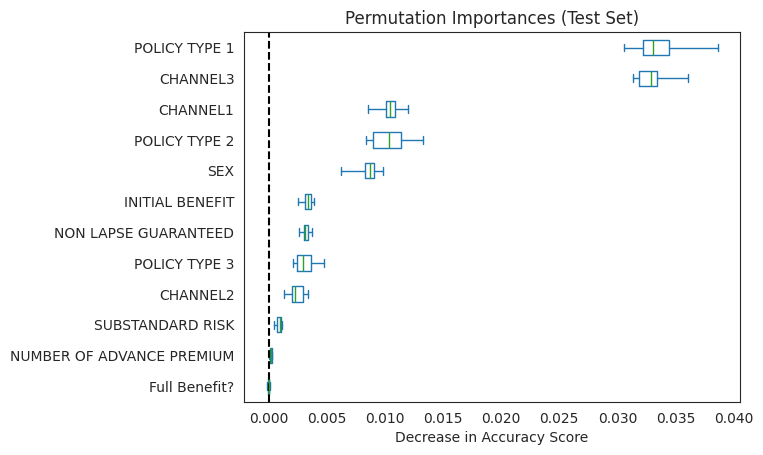

In [ ]:
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (Test Set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in Accuracy Score")

#Partial Dependence Plot

In [ ]:
numerical_features_sorted_xgb = [feature_names[i] for i in sorted_importances_idx_xgb if feature_names[i] in num_cols]
numerical_features_sorted_xgb.reverse()

In [ ]:
print(numerical_features_sorted_xgb)

['Policy Year (Decimal)', 'Premium', 'ENTRY AGE', 'BENEFIT', 'POLICY TYPE 1', 'CHANNEL3', 'CHANNEL1', 'POLICY TYPE 2', 'INITIAL BENEFIT', 'CHANNEL2', 'SUBSTANDARD RISK', 'NUMBER OF ADVANCE PREMIUM']


In [ ]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)

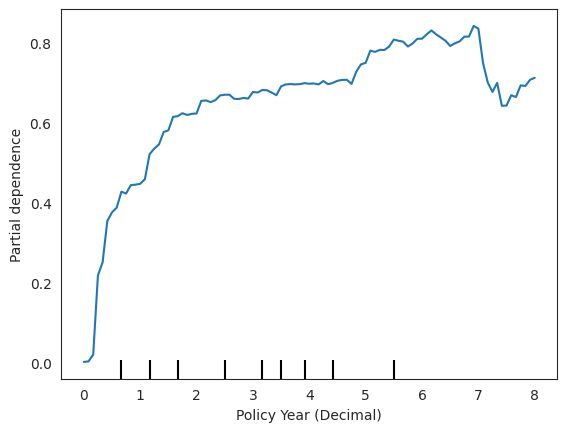

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_pipeline, X_test_df,
[(numerical_features_sorted_xgb[0])], feature_names=feature_names)

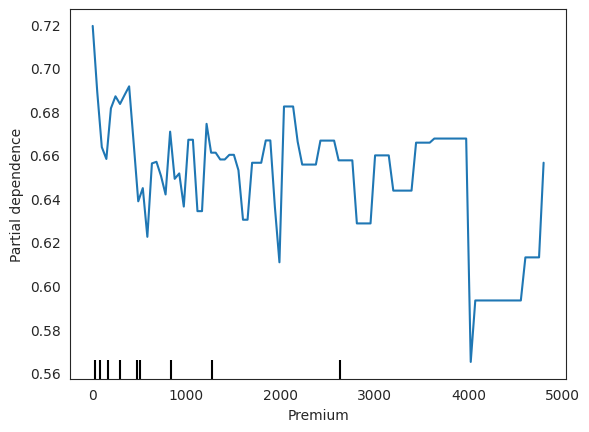

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_pipeline, X_test_df,
[(numerical_features_sorted_xgb[1])], feature_names=feature_names)

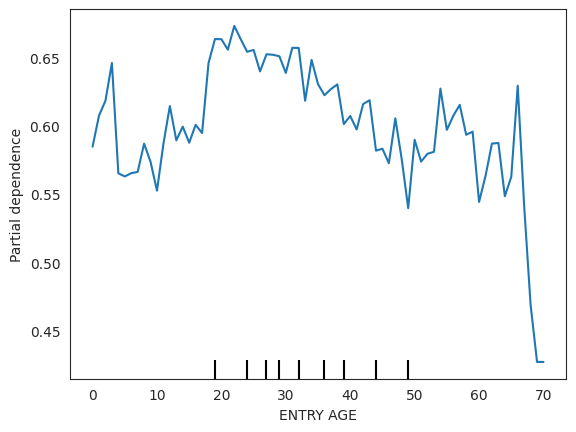

In [ ]:
PartialDependenceDisplay.from_estimator(xgb_pipeline, X_test_df,
[(numerical_features_sorted_xgb[2])], feature_names=feature_names)

#ICE

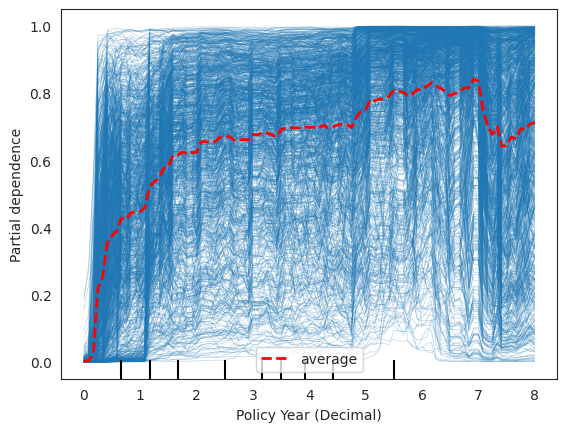

In [ ]:
disp = PartialDependenceDisplay.from_estimator(
    xgb_pipeline,
    X_test_df,
    [(numerical_features_sorted_xgb[0])],
    feature_names=feature_names,
    kind='both'
)

for ax in disp.axes_.ravel():
 for line in ax.lines:
        if line.get_linestyle() == '--':   # garis average PDP
            line.set_color('red')
            line.set_linewidth(2)
            break

for ax in disp.axes_.ravel():
    handles, labels = ax.get_legend_handles_labels()
    for h, lab in zip(handles, labels):
        if "average" in lab.lower():
            h.set_color('red')
    ax.legend()

disp.figure_.canvas.draw()

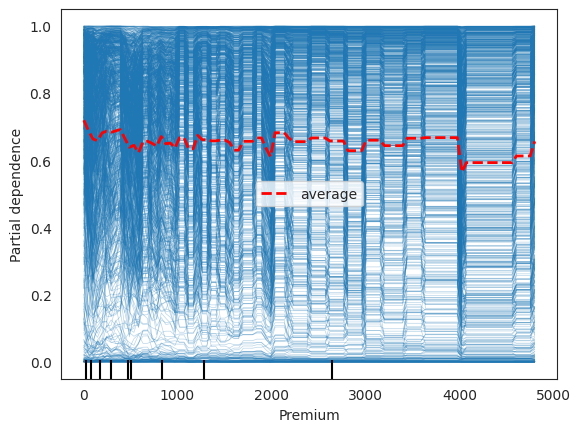

In [ ]:
disp = PartialDependenceDisplay.from_estimator(
    xgb_pipeline,
    X_test_df,
    [(numerical_features_sorted_xgb[1])],
    feature_names=feature_names,
    kind='both'
)

for ax in disp.axes_.ravel():
 for line in ax.lines:
        if line.get_linestyle() == '--':   # garis average PDP
            line.set_color('red')
            line.set_linewidth(2)
            break

for ax in disp.axes_.ravel():
    handles, labels = ax.get_legend_handles_labels()
    for h, lab in zip(handles, labels):
        if "average" in lab.lower():
            h.set_color('red')
    ax.legend()

disp.figure_.canvas.draw()

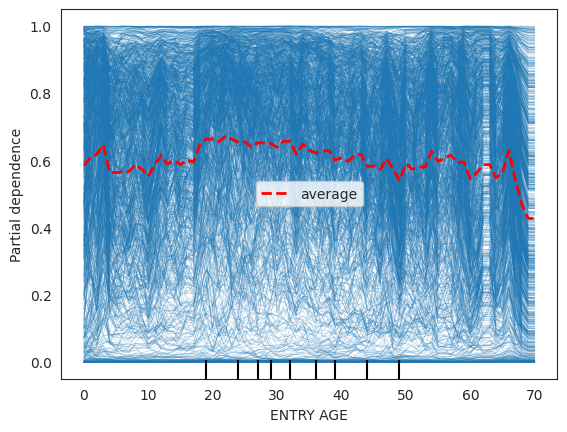

In [ ]:
disp = PartialDependenceDisplay.from_estimator(
    xgb_pipeline,
    X_test_df,
    [(numerical_features_sorted_xgb[2])],
    feature_names=feature_names,
    kind='both'
)

for ax in disp.axes_.ravel():
 for line in ax.lines:
        if line.get_linestyle() == '--':   # garis average PDP
            line.set_color('red')
            line.set_linewidth(2)
            break

for ax in disp.axes_.ravel():
    handles, labels = ax.get_legend_handles_labels()
    for h, lab in zip(handles, labels):
        if "average" in lab.lower():
            h.set_color('red')
    ax.legend()

disp.figure_.canvas.draw()